<a href="https://colab.research.google.com/github/VincentMunizAdrian/Curso_Data_Science_One/blob/main/Proyecto_Final_DS_Depresi%C3%B3n_en_alumnos_de_la_India_Vincent_Adri%C3%A1n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

-----------------------------------------------
# **Depresión en estudiantes de la India**

-----------------------------------------------
## **Índice**

1.	Introducción
2.	Preguntas de la investigación
3.	Python

  3.1 Importando librerías y Dataset

  3.2 Vista general

  3.3 Verificando si existen datos faltantes

  3.4 Cambio de valores y nombres de las columnas

  3.5 Creación de tablas de valores ID

  3.6 Creando DataFrame

4.	Análisis inicial y exploratorio de Datos

  4.1 Datos para el Análisis

  4.2 Casos en el tiempo
  
  4.3 Diferencias demográficas
  
  4.4 Factores laborales
  
  4.5 Factores académicos
  
  4.6 Factores de hábitos y antecedentes familiares

  4.7 Factores generales

5.	Conclusiones

  5.1 Casos en el tiempo

  5.2 Diferencias demográficas
  
  5.3 Factores Laborales
  
  5.4 Factores académicos
  
  5.5 Factores de hábitos y antecedentes familiares

  5.6 Conclusiones del modelo con todas las variables (General)

-----------------------------------------------
## **1. Introducción**

La salud mental de los estudiantes tanto escolares como universitarios, de variadas edades, se ha convertido en un tema de creciente interés a nivel global, especialmente en países con alta presión académica y competividad como la India. El presente estudio analiza un conjunto de datos brindados por estudiantes con el objetivo de explorar los niveles de depresión y los factores personales y contextuales que podrían estar asociados a dicha enfermedad. Las variables relevadas incluyen información demográfica (edad, género, ciudad), hábitos de vida (horas de sueño, alimentación), variables académicas y situaciones de estrés, entre otras. Este trabajo busca identificar patrones o correlaciones entre dichos factores y el nivel de depresión reportado, como así también evaluar si existen grupos más vulnerables dentro de la población estudiantil.
A partir de esta información, se plantean diversas hipótesis que permitan orientar el análisis, tales como la posible relación entre las horas de sueño, las horas dedicadas al labor o estudio, el impacto del estrés financiero en la salud mental, o si el género tiene alguna influencia significativa en los niveles de depresión observados. Asimismo, se pretende analizar si aquellos con antecedentes familiares de problemas mentales muestran mayor predisposición a síntomas depresivos. Se utilizarán herramientas de análisis exploratorio de datos en Python mediante bibliotecas como Pandas, Matplotlib o Seaborn para generar visualizaciones univariadas, bivariadas y multivariadas que permitan obtener conclusiones preliminares. Finalmente, este avance permitirá validar algunas hipótesis iniciales e identificar variables clave para futuros modelos predictivos o análisis más profundos, contribuyendo al entendimiento del fenómeno de la depresión en estudiantes universitarios de la India.

-----------------------------------------------
## **2. Preguntas de la investigación**

1. Diferencias demográficas

  ¿Existen diferencias significativas en los niveles o casos de depresión según el género y el rango etario de los estudiantes?


2. Factores laborales

  ¿La ocupación, la presión laboral, el estrés financiero y el nivel de satisfacción laboral influyen directamente en el nivel de depresión de los estudiantes encuestados?

3. Factores académicos

  ¿Influyen la carrera universitaria, la presión académica, la satisfacción académica y el desempeño académico en la aparición de síntomas depresivos?

4. Factores de hábitos y antecedentes familiares

  ¿Se observa una relación entre la cantidad de horas de sueño, los hábitos alimenticios, el historial médico familiar y la presencia de pensamientos suicidas con los niveles de depresión?

-----------------------------------------------
## **3. Python**

En este punto vamos a realizar la importación de librerías y el dataset con el cual vamos a responder las interrogantes realizadas. Además, elaboraremos algunas vistas generales, creación de tablas y verificación de datos para poner en práctica la escritura con Python.

### *3.1 Importando librerías y Dataset*

Se importan las librerías de Pandas, Matplotlib, Seaborn y Sklearn, y se carga el Dataset "Depresion de alumnos de la India" para realizar el trabajo.

In [ ]:
# ==============================
# Importamos librerías
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Para que seaborn se vea bien
sns.set(style="whitegrid", palette="Set2")
plt.rcParams.update({'figure.dpi': 110})

# ==============================
# Cargando el Dataset
# ==============================

base_depresion = "https://raw.githubusercontent.com/VincentMunizAdrian/Curso_Data_Science_One/refs/heads/main/Primer%20entrega%20-%20Depresi%C3%B3n%20en%20Alumnos%20de%20la%20India.csv"
df = pd.read_csv(base_depresion)

### *3.2 Vista general*

Dispondremos una primera vista de las primeras filas y columnas del Dataset.

In [ ]:
# ==============================
# Vista general
# ==============================

print("Primeras filas del dataset:")
display(df.head())

Primeras filas del dataset:


,ID_Estudiante,ID_Genero,Genero,Edad,Rango_etario,ID_Rango,ID_Ciudad,Nombre_ciudad,Longitud,Latitud,...,ID_Pensamientos_suicidas,Pensamientos_suicidas,Horas_labor_estudio,Estrés_financiero,ID_Estres,ID_Historial,Historial_Medico_Familiar,ID_Depresión,Depresión,Fecha_registro
0,2,2,M,33,Entre 30 a 39 años,3,530001,Visakhapatnam,83.21850,17.68680,...,1,Si,3,Nada estresado,1,0,No,1,Si,8/17/2024
1,8,1,F,24,Entre 20 a 29 años,2,560001,Bangalore,77.59460,12.97160,...,0,No,3,Poco estrés,2,1,Si,0,No,3/16/2024
2,26,2,M,31,Entre 30 a 39 años,3,190001,Srinagar,74.79740,34.08370,...,0,No,9,Nada estresado,1,1,Si,0,No,8/2/2024
3,30,1,F,28,Entre 20 a 29 años,2,221001,Varanasi,82.97390,25.31760,...,1,Si,4,Estrés extremo,5,1,Si,1,Si,6/27/2024
4,32,1,F,25,Entre 20 a 29 años,2,302001,Jaipur,75.78781,26.91962,...,1,Si,1,Nada estresado,1,0,No,0,No,1/4/2024


### *3.3 Verificando si existen datos faltantes*

Controlamos que no existan registros vacíos o nulos dentro del Dataset.

In [ ]:
# ==============================
# Datos faltantes
# ==============================

# Información general
print("\nInformación general:")
df.info()

# Cantidad de valores nulos
print("\nValores nulos por columna:")
display(df.isnull().sum())


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27895 entries, 0 to 27894
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Estudiante              27895 non-null  int64  
 1   ID_Genero                  27895 non-null  int64  
 2   Genero                     27895 non-null  object 
 3   Edad                       27895 non-null  int64  
 4   Rango_etario               27895 non-null  object 
 5   ID_Rango                   27895 non-null  int64  
 6   ID_Ciudad                  27895 non-null  int64  
 7   Nombre_ciudad              27895 non-null  object 
 8   Longitud                   27895 non-null  float64
 9   Latitud                    27895 non-null  float64
 10  ID_Ocupación               27895 non-null  int64  
 11  Ocupación                  27895 non-null  object 
 12  Presión_academica          27895 non-null  object 
 13  ID_Presión_Acad         

,0
ID_Estudiante,0
ID_Genero,0
Genero,0
Edad,0
Rango_etario,0
ID_Rango,0
ID_Ciudad,0
Nombre_ciudad,0
Longitud,0
Latitud,0


### *3.4 Cambio de valores y nombres de las columnas*

Controlamos los nombres de las columnas del trabajo y cambiamos el valor de la columna Fecha_registro para que tenga un valor datetime.

In [ ]:
# ============================================================
# Cambiamos valores y Nombres de las columnas
# ============================================================

# Nombres de las columnas
print("\nNombres de las columnas")
print(df.columns.tolist())

# Cambio valor columna Fecha_registro
df['Fecha_registro'] = pd.to_datetime(df['Fecha_registro'])
print(f"\nNuevo de valor de los registros en la columna fecha ===> {df['Fecha_registro'].dtypes}")


Nombres de las columnas
['ID_Estudiante', 'ID_Genero', 'Genero', 'Edad', 'Rango_etario', 'ID_Rango', 'ID_Ciudad', 'Nombre_ciudad', 'Longitud', 'Latitud', 'ID_Ocupación', 'Ocupación', 'Presión_academica', 'ID_Presión_Acad', 'Presión_laboral', 'ID_Presión_Lab', 'ID_Desempeño', 'Satisfacción_academica', 'ID_Satisfacción_Acad', 'Satisfacción_laboral', 'ID_Satisfacción_Lab', 'Horas_sueño', 'ID_Horas_Sueño', 'Alimentación', 'ID_Alimentación', 'ID_Carrera', 'Carrera', 'ID_Pensamientos_suicidas', 'Pensamientos_suicidas', 'Horas_labor_estudio', 'Estrés_financiero', 'ID_Estres', 'ID_Historial', 'Historial_Medico_Familiar', 'ID_Depresión', 'Depresión', 'Fecha_registro']

Nuevo de valor de los registros en la columna fecha ===> datetime64[ns]


### *3.5 Creación de tablas de valores ID*

Creamos tablas con sus valores calificativos y sus correspondientes valores numéricos ID.

In [ ]:
# ==============================
# Valores de cada ID
# ==============================

# Tabla genero
tabla_genero = df[['ID_Genero', 'Genero']].sort_values('ID_Genero').drop_duplicates().reset_index(drop=True)

# Tabla rango
tabla_rango = df[['ID_Rango', 'Rango_etario']].sort_values('ID_Rango').drop_duplicates().reset_index(drop=True)

# Tabla ocupación
tabla_ocupacion = df[['ID_Ocupación', 'Ocupación']].sort_values('ID_Ocupación').drop_duplicates().reset_index(drop=True)

# Tabla presión academica
tabla_pres_acad = df[['ID_Presión_Acad', 'Presión_academica']].sort_values('ID_Presión_Acad').drop_duplicates().reset_index(drop=True)

# Tabla presión laboral
tabla_pres_lab = df[['ID_Presión_Lab', 'Presión_laboral']].sort_values('ID_Presión_Lab').drop_duplicates().reset_index(drop=True)

# Tabla satisfacción academica
tabla_satisf_acad = df[['ID_Satisfacción_Acad', 'Satisfacción_academica']].sort_values('ID_Satisfacción_Acad').drop_duplicates().reset_index(drop=True)

# Tabla satisfacción laboral
tabla_satisf_lab = df[['ID_Satisfacción_Lab', 'Satisfacción_laboral']].sort_values('ID_Satisfacción_Lab').drop_duplicates().reset_index(drop=True)

# Tabla horas sueño
tabla_horas_sueño = df[['ID_Horas_Sueño', 'Horas_sueño']].sort_values('ID_Horas_Sueño').drop_duplicates().reset_index(drop=True)

# Tabla alimentacion
tabla_alimentacion = df[['ID_Alimentación', 'Alimentación']].sort_values('ID_Alimentación').drop_duplicates().reset_index(drop=True)

# Tabla carrera
tabla_carrera = df[['ID_Carrera', 'Carrera']].sort_values('ID_Carrera').drop_duplicates().reset_index(drop=True)

# Tabla pensamientos
tabla_pensamientos = df[['ID_Pensamientos_suicidas', 'Pensamientos_suicidas']].sort_values('ID_Pensamientos_suicidas').drop_duplicates().reset_index(drop=True)

# Tabla estres financiero
tabla_estres = df[['ID_Estres', 'Estrés_financiero']].sort_values('ID_Estres').drop_duplicates().reset_index(drop=True)

# Tabla historia
tabla_historial = df[['ID_Historial', 'Historial_Medico_Familiar']].sort_values('ID_Historial').drop_duplicates().reset_index(drop=True)

# Tabla depresion
tabla_depresion = df[['ID_Depresión', 'Depresión']].sort_values('ID_Depresión').drop_duplicates().reset_index(drop=True)

print("\nTabla Genero")
display(tabla_genero)
print("\nTabla Rango")
display(tabla_rango)
print("\nTabla Ocupacion")
display(tabla_ocupacion)
print("\nTabla Presión academica")
display(tabla_pres_acad)
print("\nTabla Presión laboral")
display(tabla_pres_lab)
print("\nTabla Satisfacción academica")
display(tabla_satisf_acad)
print("\nTabla Satisfacción laboral")
display(tabla_satisf_lab)
print("\nTabla Horas Sueño")
display(tabla_horas_sueño)
print("\nTabla Alimentacion")
display(tabla_alimentacion)
print("\nTabla Carrera")
display(tabla_carrera)
print("\nTabla Pensamientos")
display(tabla_pensamientos)
print("\nTabla Estres financiero")
display(tabla_estres)
print("\nTabla Historial familiar")
display(tabla_historial)
print("\nTabla Depresión")
display(tabla_depresion)


Tabla Genero


,ID_Genero,Genero
0,1,F
1,2,M



Tabla Rango


,ID_Rango,Rango_etario
0,1,Menor a 20 años
1,2,Entre 20 a 29 años
2,3,Entre 30 a 39 años
3,4,Entre 40 a 49 años
4,5,Entre 50 a 59 años



Tabla Ocupacion


...

,ID_Estres,Estrés_financiero
0,1,Nada estresado
1,2,Poco estrés
2,3,Moderado
3,4,Bastante estrés
4,5,Estrés extremo



Tabla Historial familiar


,ID_Historial,Historial_Medico_Familiar
0,0,No
1,1,Si



Tabla Depresión


,ID_Depresión,Depresión
0,0,No
1,1,Si


### *3.6 Creando DataFrame*

Seguimos trabajando la escritura en Python (Pandas) y creamos algunos DataFrames

In [ ]:
# ==============================
# Cargando DataFrames
# ==============================

# Dataframe mes y trimestre
df['Mes'] = df['Fecha_registro'].dt.month
df['Trimestre'] = df['Fecha_registro'].dt.quarter

# Dataframe registro estudiantes
df_registro = df[['ID_Estudiante', 'Mes', 'Trimestre']]

# Dataframe estudiantes por genero
df_estudiantes = df[['ID_Genero', 'Edad', 'ID_Rango', 'ID_Depresión']]

# Dataframe academia
df_academia = df[['ID_Carrera', 'ID_Satisfacción_Acad', 'ID_Presión_Acad', 'ID_Desempeño']]

# Dataframe labor
df_labor = df[['ID_Ocupación', 'ID_Satisfacción_Lab', 'ID_Presión_Lab', 'ID_Estres']]

# Dataframe salud
df_salud = df[['ID_Horas_Sueño', 'ID_Alimentación', 'ID_Pensamientos_suicidas', 'ID_Historial', 'ID_Depresión']]

# ==============================
# Visualizacion de DataFrames
# ==============================

print('\nTabla de registros')
display(df_registro.head(5))

print('\nTabla de estudiantes')
display(df_estudiantes.head(5))

print('\nTabla de registros academicos')
display(df_academia.head(5))

print('\nTabla de registros laborales')
display(df_labor.head(5))

print('\nTabla de registros de salud')
display(df_salud.head(5))


Tabla de registros


,ID_Estudiante,Mes,Trimestre
0,2,8,3
1,8,3,1
2,26,8,3
3,30,6,2
4,32,1,1



Tabla de estudiantes


,ID_Genero,Edad,ID_Rango,ID_Depresión
0,2,33,3,1
1,1,24,2,0
2,2,31,3,0
3,1,28,2,1
4,1,25,2,0



Tabla de registros academicos


,ID_Carrera,ID_Satisfacción_Acad,ID_Presión_Acad,ID_Desempeño
0,10,2,5,8.97
1,7,5,2,5.90
2,6,5,3,7.03
3,4,2,3,5.59
4,25,3,4,8.13



Tabla de registros laborales


,ID_Ocupación,ID_Satisfacción_Lab,ID_Presión_Lab,ID_Estres
0,1,3,3,1
1,1,4,1,2
2,1,3,5,1
3,1,4,3,5
4,1,1,1,1



Tabla de registros de salud


,ID_Horas_Sueño,ID_Alimentación,ID_Pensamientos_suicidas,ID_Historial,ID_Depresión
0,2,3,1,0,1
1,2,2,0,1,0
2,1,3,0,1,0
3,3,2,1,1,1
4,2,2,1,0,0


-----------------------------------------------
## **4. Análisis inicial y exploratorio de Datos**

En este trabajo se analizarán los registros obtenidos en el dataset, organizando el estudio en diferentes etapas. En primer lugar, se observarán los registros correspondientes al año 2024. Posteriormente, se realizará un análisis por factores, en función de las interrogantes planteadas en el punto 2, interpretando los datos y extrayendo hallazgos relevantes.

A continuación, los registros serán procesados para entrenar un algoritmo de clasificación, calculando métricas básicas que permitan validar o refutar el desempeño del modelo entrenado. Finalmente, se presentará un análisis global que sintetice los principales resultados y conclusiones obtenidas.

### **4.1 Datos para el Análisis**

In [ ]:
# ==============================
# Datos numericos - Columnas ID
# ==============================

col_ID_demograficas = ['ID_Genero', 'ID_Rango']
col_ID_laborales = ['ID_Presión_Lab', 'ID_Satisfacción_Lab', 'ID_Estres']
col_ID_academicas = ['ID_Carrera', 'ID_Presión_Acad', 'ID_Satisfacción_Acad']
col_ID_historial_salud = ['ID_Horas_Sueño', 'ID_Alimentación', 'ID_Pensamientos_suicidas' , 'ID_Historial']

columnas_numericas = col_ID_demograficas + col_ID_laborales + col_ID_academicas + col_ID_historial_salud

columnas_numericas

['ID_Genero',
 'ID_Rango',
 'ID_Presión_Lab',
 'ID_Satisfacción_Lab',
 'ID_Estres',
 'ID_Carrera',
 'ID_Presión_Acad',
 'ID_Satisfacción_Acad',
 'ID_Horas_Sueño',
 'ID_Alimentación',
 'ID_Pensamientos_suicidas',
 'ID_Historial']

In [ ]:
# =========================================
# Datos categoricos - Columnas categoricas
# =========================================

valores_categoricos = df.select_dtypes(exclude=np.number).columns.tolist()
columnas_noUso = ['Nombre_ciudad', 'Ocupación','Fecha_registro', 'Depresión']

columnas_categoricas = [col for col in valores_categoricos if col not in columnas_noUso]

cat_demograficas = ['Genero', 'Rango_etario']
cat_academicas = ['Presión_academica', 'Satisfacción_academica', 'Carrera']
cat_laborales = ['Presión_laboral', 'Satisfacción_laboral', 'Estrés_financiero']
cat_historial_salud = ['Horas_sueño', 'Alimentación', 'Pensamientos_suicidas', 'Historial_Medico_Familiar']

columnas_categoricas

['Genero',
 'Rango_etario',
 'Presión_academica',
 'Presión_laboral',
 'Satisfacción_academica',
 'Satisfacción_laboral',
 'Horas_sueño',
 'Alimentación',
 'Carrera',
 'Pensamientos_suicidas',
 'Estrés_financiero',
 'Historial_Medico_Familiar']

Función para evaluar eficiencia de los modelos

In [ ]:
def evaluar_modelo(nombre_modelo, accuracy, roc_auc, umbral_acc=0.75, umbral_auc=0.5):
    print(f"\nModelo: {nombre_modelo}")
    print(f"- Accuracy: {accuracy:.2f}")
    print(f"- AUC: {roc_auc:.2f}")

    if accuracy >= umbral_acc and roc_auc >= umbral_auc:
        print("El modelo predice por encima de los umbrales → Eficiente")
    else:
        print("El modelo no alcanza los umbrales → No es eficiente")

----------------------------
### **4.2 Casos en el tiempo**

En los siguientes gráficos podemos observar el registro de los casos positivos y negativos en el transcurso de un año, en el primer grafico se verá un progreso de manera mensual y en el segundo de manera trimestral.

#### *Primero registramos el año en que se realizo la encuesta*

In [ ]:
# ==============================
# Selección del año a graficar
# ==============================

año_registro = df["Fecha_registro"].dt.year.max()
df_year = df[df["Fecha_registro"].dt.year == año_registro].copy()

print(f"Año graficado: {año_registro}")

Año graficado: 2024


#### *Casos por mes*

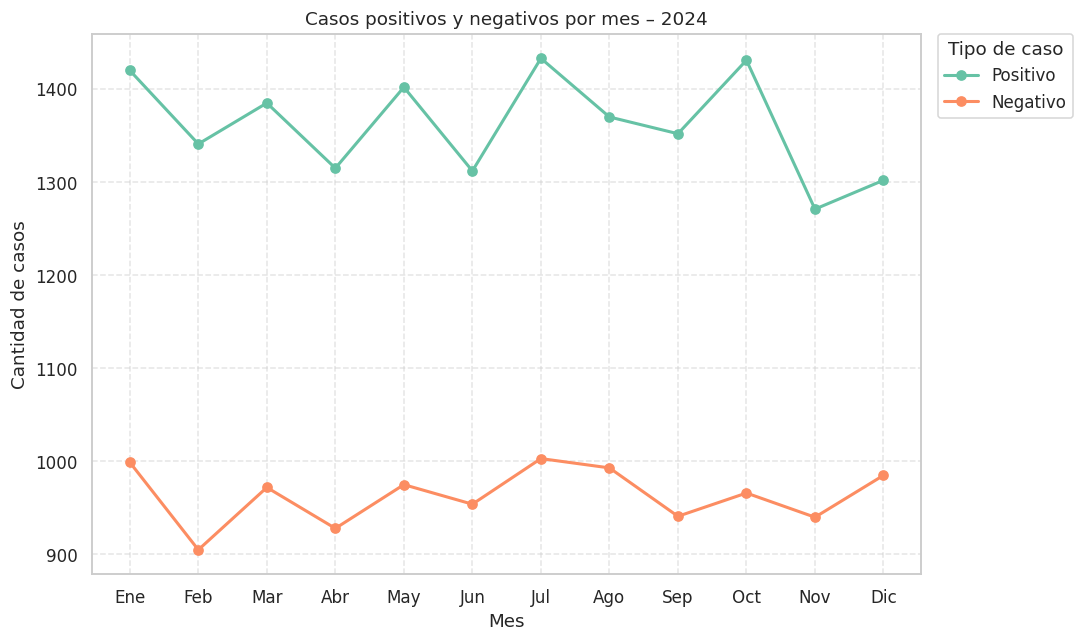

In [ ]:
# ==============================
# Grafico Mensual
# ==============================

# Conteo por mes y por Depresión
mensual = (
    df_year.groupby([df_year["Fecha_registro"].dt.month, "Depresión"])
    .size()
    .unstack(fill_value=0)
)

# Aseguramos los 12 meses (1..12) aunque no haya datos en alguno
mensual = mensual.reindex(range(1, 12+1), fill_value=0)

# Renombramos columnas a Positivo / Negativo - Cambia "Si"/"Sí" por "Positivo" (para unificar) y "No" por "Negativo"
mensual = mensual.rename(columns={"Si": "Positivo", "Sí": "Positivo", "No": "Negativo"})

# Nos quedamos solo con las dos series clave y garantizamos que existan
mensual = mensual.reindex(columns=["Positivo", "Negativo"], fill_value=0)

# Etiquetas de meses
meses_etiqueta = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

# Plot
fig, ax = plt.subplots(figsize=(10,6))
mensual.plot(ax=ax, marker="o", linewidth=2)
ax.set_title(f"Casos positivos y negativos por mes – {año_registro}")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de casos")
ax.set_xticks(range(1,13))
ax.set_xticklabels(meses_etiqueta)
ax.grid(True, linestyle="--", alpha=0.5)

# Ajustes y gráfico
leg = ax.legend(title="Tipo de caso", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.subplots_adjust(right=0.80)
plt.tight_layout()
plt.show()

##### Analisis por mes

In [ ]:
# ==============================
# Cantidad de casos por MES
# ==============================
df['Mes'] = df['Fecha_registro'].dt.month

casos_mes = (
    df.groupby(['Mes', 'Depresión'])['ID_Depresión']
    .count()
    .unstack(fill_value=0)
    .rename(columns={'Si': 'Positivo', 'No': 'Negativo'})
)

print("\n=== Cantidad de casos por mes ===")
display(casos_mes)

print("\n=== Análisis descriptivo (mensual) ===")
display(casos_mes.describe())


=== Cantidad de casos por mes ===


Depresión,Negativo,Positivo
Mes,,
1,999,1420
2,905,1341
3,972,1385
4,928,1315
5,975,1402
6,954,1312
7,1003,1433
8,993,1370
9,941,1352



=== Análisis descriptivo (mensual) ===


Depresión,Negativo,Positivo
count,12.000000,12.000000
mean,963.416667,1361.166667
std,30.443564,54.340397
min,905.000000,1271.000000
25%,940.750000,1314.250000
50%,969.000000,1361.000000
75%,987.000000,1406.500000
max,1003.000000,1433.000000


#### *Casos por trimestre*

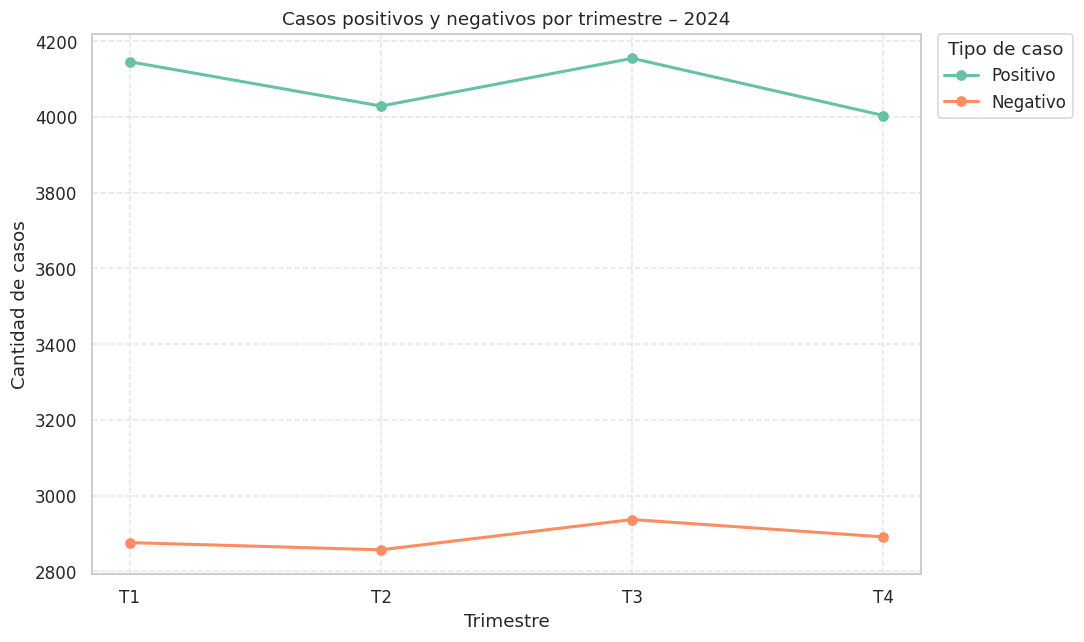

In [ ]:
# ==============================
# Grafico Trimestral
# ==============================

trimestral = (
    df_year.groupby([df_year["Fecha_registro"].dt.quarter, "Depresión"])
    .size()
    .unstack(fill_value=0)
)

# Aseguramos T1..T4
trimestral = trimestral.reindex([1,2,3,4], fill_value=0)

# Renombramos y seleccionamos columnas
trimestral = trimestral.rename(columns={"Si": "Positivo", "Sí": "Positivo", "No": "Negativo"})
trimestral = trimestral.reindex(columns=["Positivo", "Negativo"], fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(10,6))
trimestral.plot(ax=ax, marker="o", linewidth=2)
ax.set_title(f"Casos positivos y negativos por trimestre – {año_registro}")
ax.set_xlabel("Trimestre")
ax.set_ylabel("Cantidad de casos")
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(["T1","T2","T3","T4"])
ax.grid(True, linestyle="--", alpha=0.5)

# Ajustes y gráfico
leg = ax.legend(title="Tipo de caso", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.subplots_adjust(right=0.80)
plt.tight_layout()
plt.show()

##### Analisis por trimestre

In [ ]:
# ============================================================
# Cantidad de casos por Trimestre
# ============================================================
df['Trimestre'] = df['Fecha_registro'].dt.quarter

casos_trim = (
    df.groupby(['Trimestre', 'Depresión'])['ID_Depresión']
    .count()
    .unstack(fill_value=0)
    .rename(columns={'Si': 'Positivo', 'No': 'Negativo'})
)

print("\n=== Cantidad de casos por trimestre ===")
display(casos_trim)

print("\n=== Análisis descriptivo (trimestral) ===")
display(casos_trim.describe())


=== Cantidad de casos por trimestre ===


Depresión,Negativo,Positivo
Trimestre,,
1,2876,4146
2,2857,4029
3,2937,4155
4,2891,4004



=== Análisis descriptivo (trimestral) ===


Depresión,Negativo,Positivo
count,4.000000,4.0000
mean,2890.250000,4083.5000
std,34.130876,78.1217
min,2857.000000,4004.0000
25%,2871.250000,4022.7500
50%,2883.500000,4087.5000
75%,2902.500000,4148.2500
max,2937.000000,4155.0000


--------------------------------------------------
#### *Interpretación de los resultados obtenidos*

---
##### Análisis Mensual – Evolución de casos de depresión (Positivos vs Negativos)

Valores clave observados:

|Métrica           |  Negativos	 |  Positivos  |
|------------------|:-----------:|-------------|  
|Media (promedio)	 |  963 casos	 |   1361 casos|
|Desvío estándar	 |  30.4	     |   54.3      |
|Mínimo	           |  905        |   1271      |
|Máximo            |  1003       |   1433      |

*   Los casos positivos superan claramente a los negativos todos los meses.
 *   Promedio mensual: unos 1361 casos positivos vs 963 negativos.

* Variación mensual relativamente baja: los casos no suben ni bajan bruscamente entre meses.

 * Desvío estándar pequeño → estabilidad en el tiempo.

* Mes más alto de positivos: 1433 casos.

* Mes más bajo de positivos: 1271 casos.

 * diferencia máxima de aproximadamente 162 casos entre el mejor y peor mes.

* En los negativos, diferencia entre mínimo y máximo es solo de 98 casos.

---
##### Análisis Trimestral - Evolución de casos de depresión (Positivos vs Negativos)

Valores clave observados:
|Métrica           |  Negativos	 |  Positivos  |
|------------------|:-----------:|-------------|  
|Media (promedio)	 |  2890 casos |   4083 casos|
|Desvío estándar	 |  34.1	     |   78.1      |
|Mínimo	           |  2857       |   4004      |
|Máximo            |  2937       |   4155      |

* En perspectiva trimestral, se confirma la misma relación: positivos > negativos.

* El promedio por trimestre es de 4083 casos positivos frente a 2890 negativos.

* El desvío estándar también es bajo, lo que confirma estabilidad entre trimestres.

* Los valores máximos y mínimos están bastante próximos → no hay trimestre con salto brusco.

-------------------------------------
### **4.3 Diferencias demográficas**

En esta sección analizamos si las características demográficas básicas, como el género y la edad, se encuentran asociadas con la presencia de depresión en los estudiantes. Para ello, se graficó la distribución de casos positivos y negativos de depresión según género y rangos etarios, a fin de identificar si existen grupos poblacionales más afectados.

#### **Análisis Inicial**

##### *Grafico por genero y rango etario*

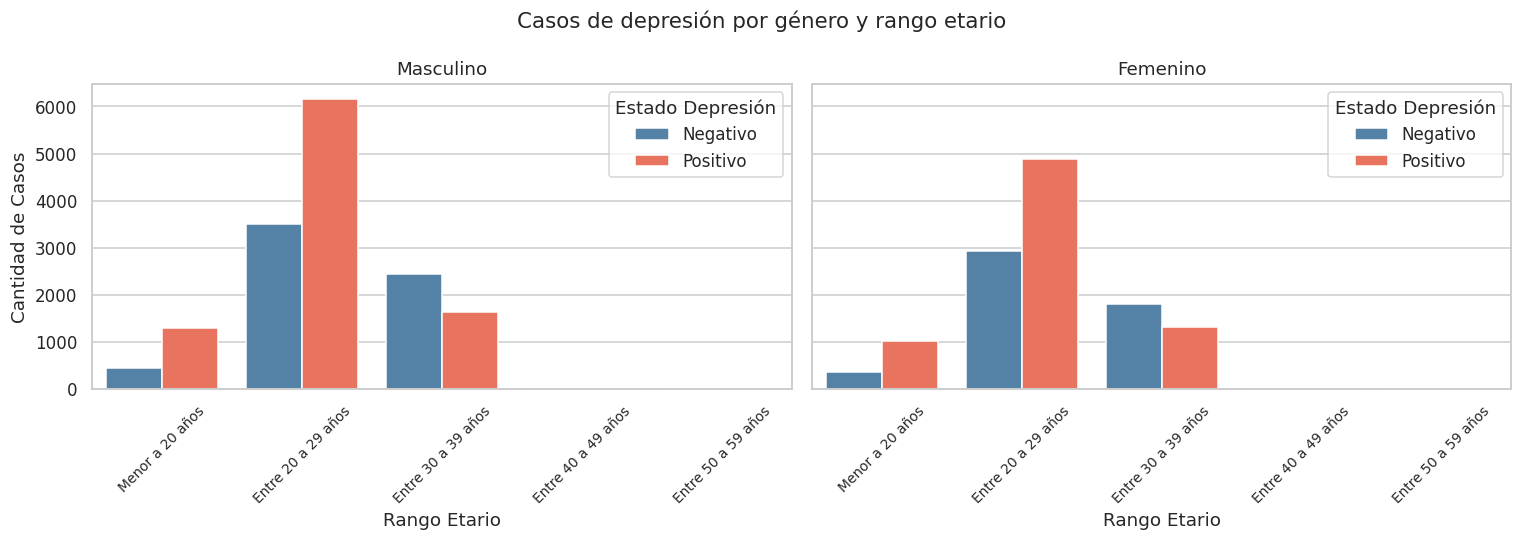


Analisis de casos sobre las mujeres


,ID_Genero,Edad,ID_Rango,ID_Depresión
count,12350.0,12350.000000,12350.000000,12350.000000
mean,1.0,25.772551,2.142834,0.584534
std,0.0,4.905274,0.591737,0.492822
min,1.0,18.000000,1.000000,0.000000
25%,1.0,21.000000,2.000000,0.000000
50%,1.0,25.000000,2.000000,1.000000
75%,1.0,30.000000,3.000000,1.000000
max,1.0,58.000000,5.000000,1.000000



Analisis de casos sobre los hombres


,ID_Genero,Edad,ID_Rango,ID_Depresión
count,15545.0,15545.000000,15545.000000,15545.000000
mean,2.0,25.861435,2.151560,0.586362
std,0.0,4.906299,0.596941,0.492501
min,2.0,18.000000,1.000000,0.000000
25%,2.0,21.000000,2.000000,0.000000
50%,2.0,26.000000,2.000000,1.000000
75%,2.0,30.000000,3.000000,1.000000
max,2.0,59.000000,5.000000,1.000000


In [ ]:
# Preparación del DataFrame con nombres de rango y estado de depresión
df_estudiantes_graf = df_estudiantes.merge(tabla_rango, on='ID_Rango', how='left')
df_estudiantes_graf['Estado_Dep'] = df_estudiantes_graf['ID_Depresión'].apply(lambda x: 'Positivo' if x == 1 else 'Negativo')

# Orden correcto deseado de los rangos etarios (as strings)
orden_rangos = tabla_rango['Rango_etario'].tolist()

# Convertimos la columna Rango_etario en categoría con orden especificado
df_estudiantes_graf['Rango_etario'] = pd.Categorical(
    df_estudiantes_graf['Rango_etario'],
    categories=orden_rangos,
    ordered=True
)

# Agrupar por género, rango y estado de depresión y recuento
agrupar = df_estudiantes_graf.groupby(['ID_Genero', 'Rango_etario', 'Estado_Dep'], observed=True).size().reset_index(name='Cantidad')

# Fusionar con tabla_genero para obtener etiquetas de género
agrupar = agrupar.merge(tabla_genero, on='ID_Genero', how='left')

# Paleta de colores
colores = {'Negativo': 'steelblue', 'Positivo': 'tomato'}

# Graficamos
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# Masculino
homb_group = agrupar[agrupar['ID_Genero'] == 2]
sns.barplot(data=homb_group, x='Rango_etario', y='Cantidad', hue='Estado_Dep',
            palette=colores, ax=axes[0])
axes[0].set_title('Masculino')
axes[0].set_xlabel('Rango Etario')
axes[0].set_ylabel('Cantidad de Casos')
axes[0].legend(title='Estado Depresión')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)

# Femenino
muj_group = agrupar[agrupar['ID_Genero'] == 1]
sns.barplot(data=muj_group, x='Rango_etario', y='Cantidad', hue='Estado_Dep',
            palette=colores, ax=axes[1])
axes[1].set_title('Femenino')
axes[1].set_xlabel('Rango Etario')
axes[1].legend(title='Estado Depresión')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)

plt.suptitle('Casos de depresión por género y rango etario', fontsize=14)
plt.tight_layout()
plt.show()

# ===========
# Análisis
# ===========

# Casos mujer
print('\nAnalisis de casos sobre las mujeres')
mujer_rango = df_estudiantes['ID_Genero'] == 1

display(df_estudiantes[mujer_rango].describe())

# Casos hombre
print('\nAnalisis de casos sobre los hombres')
hombre_rango = df_estudiantes['ID_Genero'] == 2

display(df_estudiantes[hombre_rango].describe())

--------------------------------------------------
##### *Interpretación de los resultados obtenidos*
--------------------------------------------------

Análisis: Diferencias demográficas

Sobre mujeres

| Variable      | Promedio (media) |
| ------------- | ---------------- |
| Edad          | 25.77 años       |
| ID_Rango      | ~2.14            |
| ID_Depresión  | ~0.584           |


* La edad promedio de las mujeres en la muestra es 25,8 años, con un rango que va de 18 a 58.

* El valor medio de ID_Depresión ≈ 0,584 indica que más de la mitad de los casos femeninos presentaron depresión (siendo 1 depresión sí, 0 depresión no).

* El 50% en ID_Depresión es 1 → es decir, al menos el 50% de las mujeres tienen depresión (resultado consistente con el gráfico anterior).

* La mayor concentración etaria es entre 21 y 30 años (percentiles 25% al 75%).

Sobre hombres

| Variable      | Promedio (media) |
| ------------- | ---------------- |
| Edad          | 25.86 años       |
| ID\_Rango     | \~2.15           |
| ID\_Depresión | \~0.586          |

* La edad promedio masculina es prácticamente igual: 25,86 años.

* El valor medio de ID_Depresión ≈ 0,586 indica que un porcentaje similar de hombres está afectado por depresión, aunque levemente menor que en mujeres.

* El 75% sigue siendo 1 → también hay una concentración alta de casos positivos.

#### **Análisis Exploratorio**

##### Matriz de Correlación

Se analizó la correlación entre los factores demograficos y la variable objetivo (Target) ID_Depresión.

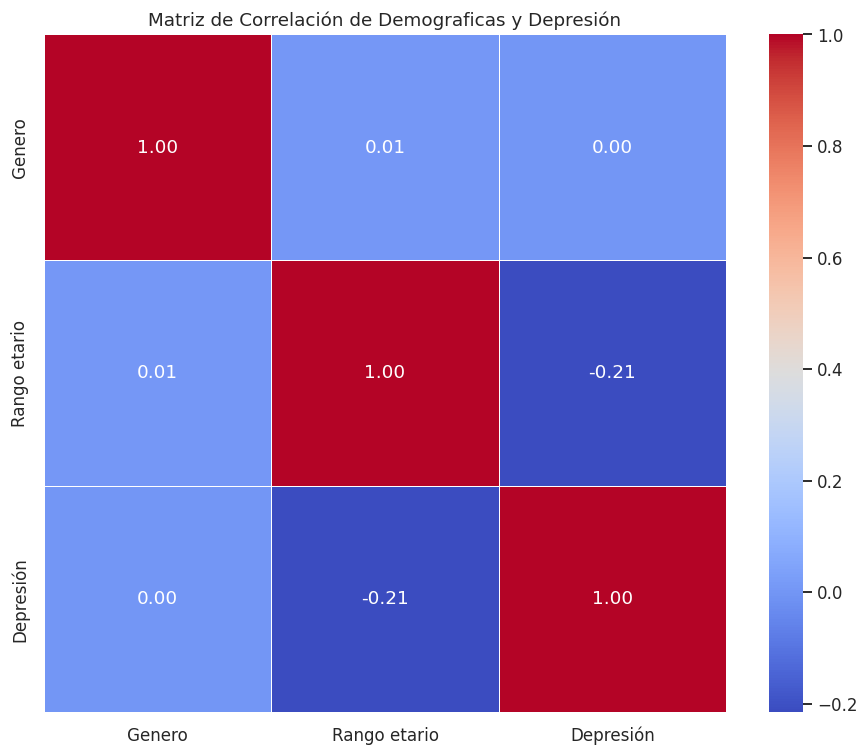


Correlaciones con la variable 'Depresión':


,Depresión
Depresión,1.000000
Genero,0.001843
Rango etario,-0.214710


In [ ]:
# Diccionario de mapeo de nombres
rename_ID_dem = {
    'ID_Genero': 'Genero',
    'ID_Rango': 'Rango etario',
    'ID_Depresión': 'Depresión'
}

# Seleccionar variables
corr_features_demograficas = col_ID_demograficas + ['ID_Depresión']
correlation_matrix_demog = df[corr_features_demograficas].corr()

# Renombrar filas y columnas con nombres amigables
correlation_matrix_demog = correlation_matrix_demog.rename(index=rename_ID_dem, columns=rename_ID_dem)

# Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_demog, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Demograficas y Depresión')
plt.show()

# Mostrar correlaciones ordenadas con el target
print("\nCorrelaciones con la variable 'Depresión':")
display(correlation_matrix_demog['Depresión'].sort_values(ascending=False))

##### Procesamiento de datos

In [ ]:
# Definimos las columnas que se usarán como características
features_demograficos = col_ID_demograficas + cat_demograficas

# Variable objetivo (lo que queremos predecir: depresión Sí/No)
target = 'ID_Depresión'

# Definimos características (X) y la variable objetivo (y)
X_demograficos = df[features_demograficos]
y = df[target]

# Verificamos
print(col_ID_demograficas)
print(cat_demograficas)
print(features_demograficos)
print(target)

['ID_Genero', 'ID_Rango']
['Genero', 'Rango_etario']
['ID_Genero', 'ID_Rango', 'Genero', 'Rango_etario']
ID_Depresión


In [ ]:
# ==================
# ColumnTransformer
# ==================

# Definimos un ColumnTransformer
preprocessor_demografico = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_ID_demograficas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_demograficas)
    ],
    remainder='passthrough'
)

preprocessor_demografico

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['ID_Genero', 'ID_Rango']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Genero', 'Rango_etario'])])

In [ ]:
# =========================
# División del dataset
# =========================

# Separa los datos en entrenamiento y prueba (75%-25%)
X_train_dem, X_test_dem, y_train_dem, y_test_dem = train_test_split(X_demograficos, y, test_size=0.25, random_state=42, stratify=y)

# Verificamos tamaños de los conjuntos
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train_dem.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test_dem.shape}")
print(f"Tamaño del conjunto de entrenamiento (y_train): {y_train_dem.shape}")
print(f"Tamaño del conjunto de prueba (y_test): {y_test_dem.shape}")

# Mostramos la distribución de la variable objetivo en Train y Test
print("\nDistribución de la variable objetivo en Train vs Test:")
print(f"Train: \n{y_train_dem.value_counts(normalize=True)}")
print(f"Test: \n{y_test_dem.value_counts(normalize=True)}")

Tamaño del conjunto de entrenamiento (X_train): (20921, 4)
Tamaño del conjunto de prueba (X_test): (6974, 4)
Tamaño del conjunto de entrenamiento (y_train): (20921,)
Tamaño del conjunto de prueba (y_test): (6974,)

Distribución de la variable objetivo en Train vs Test:
Train: 
ID_Depresión
1    0.585536
0    0.414464
Name: proportion, dtype: float64
Test: 
ID_Depresión
1    0.585604
0    0.414396
Name: proportion, dtype: float64


##### Construcción y Entrenamiento del Modelo (Random Forest)

In [ ]:
# ========================================
# Construcción y entrenamiento del modelo
# ========================================

# Pipeline
model_pipeline_demografico = Pipeline(steps=[
    ('preprocessor', preprocessor_demografico),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Entrenamos el modelo con los datos de entrenamiento
model_pipeline_demografico.fit(X_train_dem, y_train_dem)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ID_Genero', 'ID_Rango']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Genero',
                                                   'Rango_etario'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

##### Evaluación del Modelo y Accuracy

In [ ]:
# =================================
# Evaluación del modelo y Accuracy
# =================================

# Predicciones finales (clase) y probabilidades (para ROC/AUC)
y_pred_dem = model_pipeline_demografico.predict(X_test_dem)
y_pred_proba_dem = model_pipeline_demografico.predict_proba(X_test_dem)[:, 1]

# Accuracy global
accuracy_dem = accuracy_score(y_test_dem, y_pred_dem)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy_dem:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.6368


##### Matriz de confusión y reporte


--- Matriz de Confusión ---


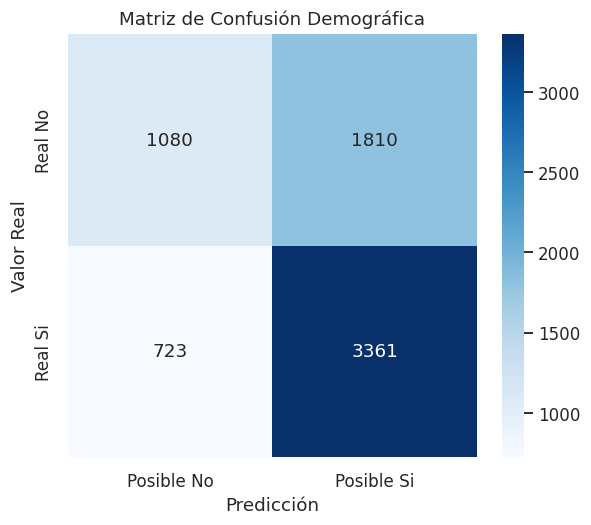

Verdaderos Negativos (TN): 1080
Falsos Positivos (FP): 1810
Falsos Negativos (FN): 723
Verdaderos Positivos (TP): 3361

--- Informe de Clasificación ---
              precision    recall  f1-score   support

Depresión No       0.60      0.37      0.46      2890
Depresión Si       0.65      0.82      0.73      4084

    accuracy                           0.64      6974
   macro avg       0.62      0.60      0.59      6974
weighted avg       0.63      0.64      0.62      6974



In [ ]:
# ====================
# Matriz de confusión
# ====================

# Gráfico de la matriz
print("\n--- Matriz de Confusión ---")
cm_dem = confusion_matrix(y_test_dem, y_pred_dem)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dem, annot=True, fmt='d', cmap='Blues', xticklabels=['Posible No', 'Posible Si'], yticklabels=['Real No', 'Real Si'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Demográfica')
plt.show()

# Detalle numérico
print(f"Verdaderos Negativos (TN): {cm_dem[0,0]}")
print(f"Falsos Positivos (FP): {cm_dem[0,1]}")
print(f"Falsos Negativos (FN): {cm_dem[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_dem[1,1]}")

# Reporte de clasificación con precisión, recall y f1-score
target_names = ['Depresión No', 'Depresión Si']
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test_dem, y_pred_dem, target_names=target_names))

##### Curva ROC y AUC

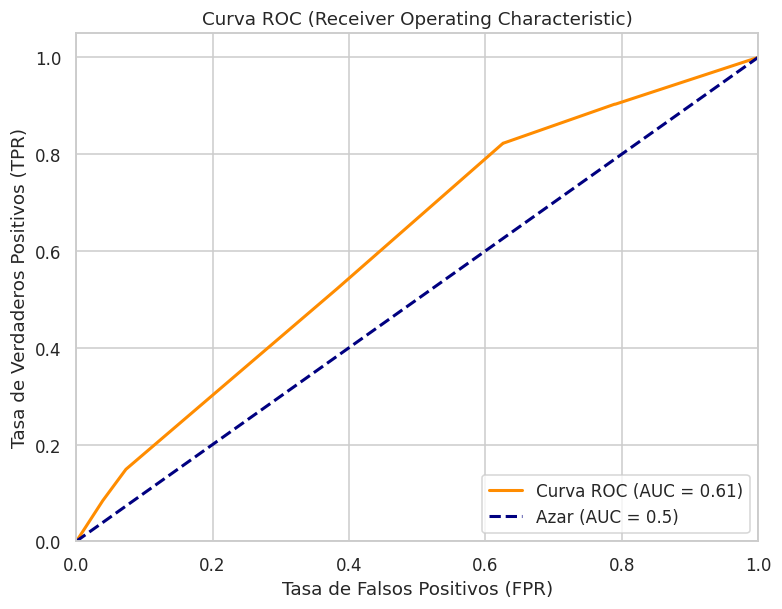


-------------------------------------
Área Bajo la Curva ROC (AUC): 0.6144


In [ ]:
# ================
# Curva ROC y AUC
# ================

# Calculamos puntos FPR/TPR y el AUC
fpr, tpr, thresholds = roc_curve(y_test_dem, y_pred_proba_dem)
roc_auc_dem = auc(fpr, tpr)

# Graficamos la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_dem:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

# Imprimimos el valor final del AUC
print("\n-------------------------------------")
print(f"Área Bajo la Curva ROC (AUC): {roc_auc_dem:.4f}")

##### Conclusión del modelo

In [ ]:
evaluar_modelo("model_pipeline_demografico", accuracy_dem, roc_auc_dem)


Modelo: model_pipeline_demografico
- Accuracy: 0.64
- AUC: 0.61
El modelo no alcanza los umbrales → No es eficiente


---
### **4.4 Factores laborales**

A continuación se evalúa si ciertos factores vinculados a la vida laboral o económica influyen en el bienestar emocional de los estudiantes. Se analizan variables como la presión laboral, el estrés financiero y la satisfacción laboral, observando si presentan relación con los niveles de depresión. La ocupación fue descartada como variable de interés debido a que la gran mayoría de los encuestados se identificaron como estudiantes.

#### **Análisis Inicial**

##### *Función para gráficos*

Para empezar obtendremos los nombres de las columnas que usaremos, crearemos funciones para ordenar el etiquetado y definiremos variables para el orden categorico correcto.

In [ ]:
# Nos quedamos solo con las columnas que usaremos
cols_base = ['Ocupación', 'Presión_laboral', 'Estrés_financiero', 'Satisfacción_laboral', 'Depresión']
df_limpio = df[cols_base].dropna(how='any').copy()

def orden_etiquetas(ax, max_chars=18):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append("\n".join(wrap(text, max_chars)))
    ax.set_xticklabels(labels, rotation=0)

# Intentamos construir órdenes categóricos con los IDs si están disponibles
def get_order(df, id_col, label_col):
    if id_col in df.columns:
        return (df[[id_col, label_col]]
                .dropna()
                .drop_duplicates()
                .sort_values(id_col)[label_col]
                .tolist()
               )
    return sorted(df[label_col].dropna().unique().tolist())

orden_presion = get_order(df, 'ID_Presión_Lab', 'Presión_laboral')
orden_estres = get_order(df, 'ID_Estres', 'Estrés_financiero')
orden_satis = get_order(df, 'ID_Satisfacción_Lab', 'Satisfacción_laboral')
orden_dep = get_order(df, 'ID_Depresión', 'Depresión')

##### *Conteo por ocupación de los encuestados*

Primero contaremos por ocupación de los encuestados a que se dedica o si tiene alguna profesión además de estudiar.

In [ ]:
# =======================================
# Composición de la Ocupación (texto)
# =======================================
conteo_ocupacion = df['Ocupación'].value_counts(dropna=False)

total_encuestados = conteo_ocupacion.sum()
estudiantes = conteo_ocupacion[conteo_ocupacion.index.str.contains("estudiant", case=False, na=False)].sum()
porcentaje_estudiantes = estudiantes / total_encuestados * 100

print(f"Del total de {total_encuestados} encuestados, {estudiantes} ({porcentaje_estudiantes:.1f}%) se identifican como estudiantes.")
print("Por este motivo, no se grafican las diferencias por ocupación ya que el resto de categorías son marginales.")

Del total de 27895 encuestados, 27864 (99.9%) se identifican como estudiantes.
Por este motivo, no se grafican las diferencias por ocupación ya que el resto de categorías son marginales.


##### *Definición de los graficos de barras apilados*

Formulamos una función que usamos para observar los datos obtenidos por las distintas variables. También, creamos una tabla debajo de cada grafico con los valores obtenidos para su analisis.

In [ ]:
# ============================================================================
# Funcion para Grafico de barras apiladas en %: Factor laboral vs. Depresión
# ============================================================================

# Genera un gráfico de barras apiladas en % usando una tabla cruzada normalizada por fila.

def plot_stacked_pct(df_in, x_col, hue_col, x_order=None, hue_order=None, title=''):
    tab = pd.crosstab(df_in[x_col], df_in[hue_col], normalize='index') * 100

    # Reordenamos filas y columnas si hay órdenes
    if x_order is not None:
        # Solo mantenemos categorías que existan en los datos
        x_order = [c for c in x_order if c in tab.index]
        tab = tab.reindex(index=x_order)
    if hue_order is not None:
        hue_order = [c for c in hue_order if c in tab.columns]
        tab = tab.reindex(columns=hue_order)

    ax = tab.plot(kind='bar', stacked=True, figsize=(9, 5), edgecolor='black')
    ax.set_ylim(0, 100)
    ax.set_ylabel('% dentro de cada categoría')
    ax.set_xlabel(x_col.replace('_', ' '))
    ax.set_title(title)
    orden_etiquetas(ax, max_chars=14)
    ax.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left')

    # Etiquetas centradas con %
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

    plt.tight_layout()
    plt.show()
    return tab


##### *Grafico casos de depresión en funcion a la presión laboral*

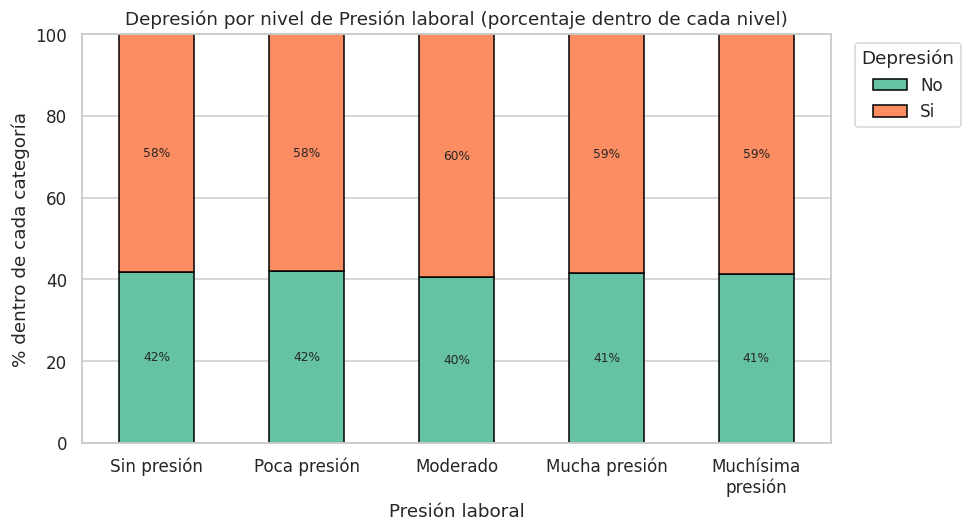

Tabla (%) Presión laboral vs Depresión


Depresión,No,Si
Presión_laboral,,
Sin presión,41.9,58.1
Poca presión,42.1,57.9
Moderado,40.5,59.5
Mucha presión,41.5,58.5
Muchísima presión,41.3,58.7


In [ ]:
# =====================================
# Grafico presión laboral vs Depresión
# =====================================

tab_presion = plot_stacked_pct(
    df_limpio,
    x_col='Presión_laboral',
    hue_col='Depresión',
    x_order=orden_presion,
    hue_order=orden_dep,
    title='Depresión por nivel de Presión laboral (porcentaje dentro de cada nivel)'
)

print("Tabla (%) Presión laboral vs Depresión")
display(tab_presion.round(1))

##### *Grafico casos de depresión en funcion al estrés finaciero*

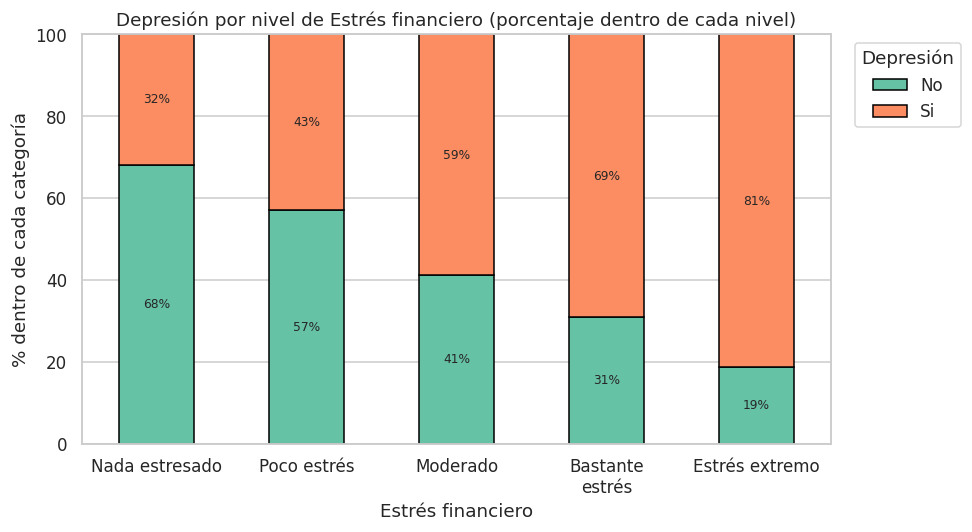

Tabla (%) Estrés financiero vs Depresión


Depresión,No,Si
Estrés_financiero,,
Nada estresado,68.1,31.9
Poco estrés,57.0,43.0
Moderado,41.1,58.9
Bastante estrés,30.9,69.1
Estrés extremo,18.7,81.3


In [ ]:
# ========================================
# Grafico Estrés financiero vs Depresión
# ========================================

tab_estres = plot_stacked_pct(
    df_limpio,
    x_col='Estrés_financiero',
    hue_col='Depresión',
    x_order=orden_estres,
    hue_order=orden_dep,
    title='Depresión por nivel de Estrés financiero (porcentaje dentro de cada nivel)'
)
print("Tabla (%) Estrés financiero vs Depresión")
display(tab_estres.round(1))

##### *Grafico casos de depresión en funcion a la satisfacción laboral*

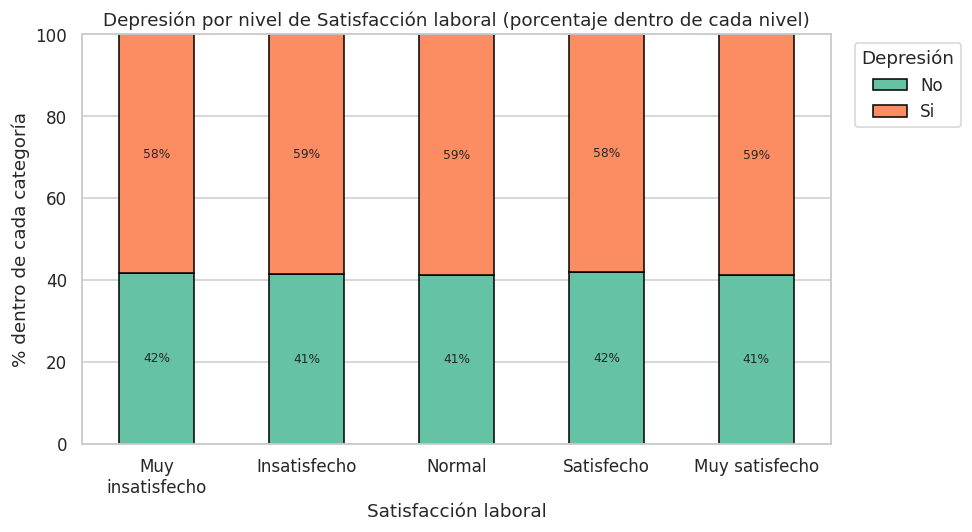

Tabla (%) Satisfacción laboral vs Depresión


Depresión,No,Si
Satisfacción_laboral,,
Muy insatisfecho,41.6,58.4
Insatisfecho,41.5,58.5
Normal,41.1,58.9
Satisfecho,42.0,58.0
Muy satisfecho,41.1,58.9


In [ ]:
# =============================================
# Grafico - Satisfacción laboral vs Depresión
# =============================================

tab_satis = plot_stacked_pct(
    df_limpio,
    x_col='Satisfacción_laboral',
    hue_col='Depresión',
    x_order=orden_satis,
    hue_order=orden_dep,
    title='Depresión por nivel de Satisfacción laboral (porcentaje dentro de cada nivel)'
)

print("Tabla (%) Satisfacción laboral vs Depresión")
display(tab_satis.round(1))

-----------------------------------------------
##### Interpretación de los resultados obtenidos
-----------------------------------------------

Análisis Presión laboral (% Depresión)

| Presión laboral   | No Depresión | Sí Depresión |
| ----------------- | ------------ | ------------ |
| Sin presión       | 41.9 %       | 58.1 %       |
| Poca presión      | 42.1 %       | 57.9 %       |
| Moderado          | 40.5 %       | 59.5 %       |
| Mucha presión     | 41.5 %       | 58.5 %       |
| Muchísima presión | 41.3 %       | 58.7 %       |

* La proporción de casos depresivos es bastante alta en todos los niveles, incluso sin presión laboral.

* Sin embargo, se observa una leve tendencia a incrementar la depresión a medida que aumenta la presión, aunque es una diferencia pequeña (de ~58% a ~59.5%).

* Conclusión: Hay una relación, pero moderada, no tan clara como en otros factores.

-------------------------------------------
Análisis Satisfacción laboral (% Depresión)

| Satisfacción laboral | No Depresión | Sí Depresión |
| -------------------- | ------------ | ------------ |
| Muy insatisfecho     | 41.6 %       | 58.4 %       |
| Insatisfecho         | 41.5 %       | 58.5 %       |
| Normal               | 41.1 %       | 58.9 %       |
| Satisfecho           | 42.0 %       | 58.0 %       |
| Muy satisfecho       | 41.1 %       | 58.9 %       |

* No hay una relación marcada con satisfacción laboral: los porcentajes son casi idénticos.

* Incluso personas “muy satisfechas” tienen niveles similares de depresión que los “muy insatisfechos”.

* Conclusión: Este factor no parece tener poder de discriminación relevante en esta muestra.

----------------------------------------
Análisis Estrés financiero (% Depresión)

| Estrés financiero | No Depresión | Sí Depresión |
| ----------------- | ------------ | ------------ |
| Nada estresado    | 68.1 %       | 31.9 %       |
| Poco estrés       | 57.0 %       | 43.0 %       |
| Moderado          | 41.1 %       | 58.9 %       |
| Bastante estrés   | 30.9 %       | 69.1 %       |
| Estrés extremo    | 18.7 %       | 81.3 %       |

* Aquí sí se ve una tendencia clara y fuerte: a más estrés financiero, mucho mayor porcentaje de depresión.

* En niveles moderados o altos, la depresión supera el 69% y llega al 81%.

* Conclusión: El estrés financiero es el factor laboral más fuertemente asociado a la depresión.

#### **Análisis Exploratorio**

##### *Matriz de Correlación*

Se analizó la correlación entre los factores laborales y la variable objetivo (Target) ID_Depresión.

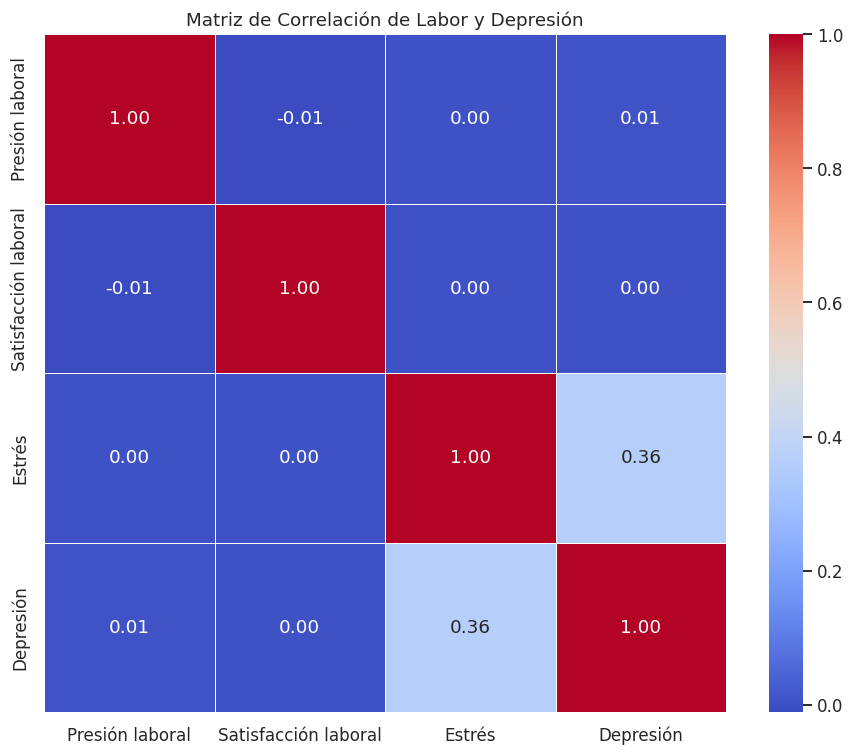


Correlaciones con la variable 'Depresión':


,Depresión
Depresión,1.000000
Estrés,0.363424
Presión laboral,0.005224
Satisfacción laboral,0.001331


In [ ]:
# Diccionario de mapeo de nombres
rename_ID_lab = {
    'ID_Presión_Lab': 'Presión laboral',
    'ID_Estres': 'Estrés',
    'ID_Satisfacción_Lab': 'Satisfacción laboral',
    'ID_Depresión': 'Depresión'
}

# Seleccionar variables
corr_features_laborales = col_ID_laborales + ['ID_Depresión']
correlation_matrix_lab = df[corr_features_laborales].corr()

# Renombrar filas y columnas con nombres amigables
correlation_matrix_lab = correlation_matrix_lab.rename(index=rename_ID_lab, columns=rename_ID_lab)

# Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_lab, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Labor y Depresión')
plt.show()

# Mostrar correlaciones ordenadas con el target
print("\nCorrelaciones con la variable 'Depresión':")
display(correlation_matrix_lab['Depresión'].sort_values(ascending=False))

##### *Procesamiento de datos*

In [ ]:
# Definimos las columnas que se usarán como características:
features_laborales = col_ID_laborales + cat_laborales

# Variable objetivo (lo que queremos predecir: depresión Sí/No)
target = 'ID_Depresión'

# Definimos características (X) y la variable objetivo (y)
X_laborales = df[features_laborales]
y = df[target]

# Verificamos
print(col_ID_laborales)
print(cat_laborales)
print(features_laborales)
print(target)

['ID_Presión_Lab', 'ID_Satisfacción_Lab', 'ID_Estres']
['Presión_laboral', 'Satisfacción_laboral', 'Estrés_financiero']
['ID_Presión_Lab', 'ID_Satisfacción_Lab', 'ID_Estres', 'Presión_laboral', 'Satisfacción_laboral', 'Estrés_financiero']
ID_Depresión


In [ ]:
# ==================
# ColumnTransformer
# ==================

# Definimos un ColumnTransformer
preprocessor_laboral = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_ID_laborales),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_laborales)
    ],
    remainder='passthrough'
)

preprocessor_laboral

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['ID_Presión_Lab', 'ID_Satisfacción_Lab',
                                  'ID_Estres']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Presión_laboral', 'Satisfacción_laboral',
                                  'Estrés_financiero'])])

In [ ]:
# =========================
# División del dataset
# =========================

# Separa los datos en entrenamiento y prueba (75%-25%)
X_train_lab, X_test_lab, y_train_lab, y_test_lab = train_test_split(X_laborales, y, test_size=0.25, random_state=42, stratify=y)

# Verificamos tamaños de los conjuntos
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train_lab.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test_lab.shape}")
print(f"Tamaño del conjunto de entrenamiento (y_train): {y_train_lab.shape}")
print(f"Tamaño del conjunto de prueba (y_test): {y_test_lab.shape}")

# Mostramos la distribución de la variable objetivo en Train y Test
print("\nDistribución de la variable objetivo en Train vs Test:")
print(f"Train: \n{y_train_lab.value_counts(normalize=True)}")
print(f"Test: \n{y_test_lab.value_counts(normalize=True)}")

Tamaño del conjunto de entrenamiento (X_train): (20921, 6)
Tamaño del conjunto de prueba (X_test): (6974, 6)
Tamaño del conjunto de entrenamiento (y_train): (20921,)
Tamaño del conjunto de prueba (y_test): (6974,)

Distribución de la variable objetivo en Train vs Test:
Train: 
ID_Depresión
1    0.585536
0    0.414464
Name: proportion, dtype: float64
Test: 
ID_Depresión
1    0.585604
0    0.414396
Name: proportion, dtype: float64


##### *Construcción y Entrenamiento del Modelo (Random Forest)*

In [ ]:
# ========================================
# Construcción y entrenamiento del modelo
# ========================================

# Pipeline
model_pipeline_laboral = Pipeline(steps=[
    ('preprocessor', preprocessor_laboral),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Entrenamos el modelo con los datos de entrenamiento
model_pipeline_laboral.fit(X_train_lab, y_train_lab)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ID_Presión_Lab',
                                                   'ID_Satisfacción_Lab',
                                                   'ID_Estres']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Presión_laboral',
                                                   'Satisfacción_laboral',
                                                   'Estrés_financiero'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

##### *Evaluación del Modelo y Accuracy*

In [ ]:
# =================================
# Evaluación del modelo y Accuracy
# =================================

# Predicciones finales (clase) y probabilidades (para ROC/AUC)
y_pred_lab = model_pipeline_laboral.predict(X_test_lab)
y_pred_proba_lab = model_pipeline_laboral.predict_proba(X_test_lab)[:, 1]

# Accuracy global
accuracy_lab = accuracy_score(y_test_lab, y_pred_lab)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy_lab:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.6415


##### *Matriz de confusión y reporte*


--- Matriz de Confusión ---


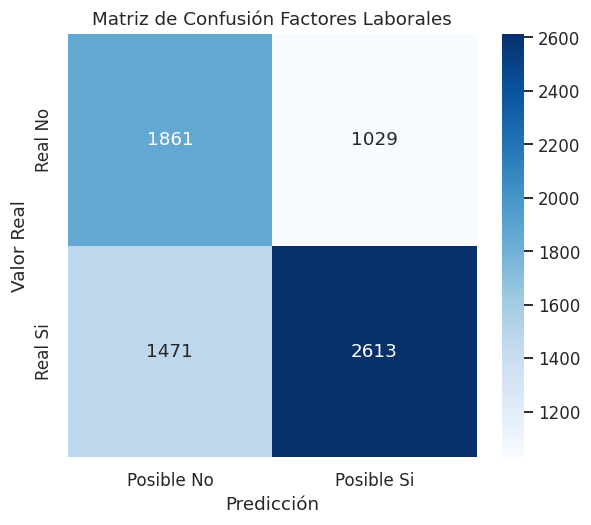

Verdaderos Negativos (TN): 1861
Falsos Positivos (FP): 1029
Falsos Negativos (FN): 1471
Verdaderos Positivos (TP): 2613

--- Informe de Clasificación ---
              precision    recall  f1-score   support

Depresión No       0.56      0.64      0.60      2890
Depresión Si       0.72      0.64      0.68      4084

    accuracy                           0.64      6974
   macro avg       0.64      0.64      0.64      6974
weighted avg       0.65      0.64      0.64      6974



In [ ]:
# ====================
# Matriz de confusión
# ====================

# Gráfico de la matriz
print("\n--- Matriz de Confusión ---")
cm_lab = confusion_matrix(y_test_lab, y_pred_lab)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lab, annot=True, fmt='d', cmap='Blues', xticklabels=['Posible No', 'Posible Si'], yticklabels=['Real No', 'Real Si'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Factores Laborales')
plt.show()

# Detalle numérico
print(f"Verdaderos Negativos (TN): {cm_lab[0,0]}")
print(f"Falsos Positivos (FP): {cm_lab[0,1]}")
print(f"Falsos Negativos (FN): {cm_lab[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_lab[1,1]}")

# Reporte de clasificación con precisión, recall y f1-score
target_names = ['Depresión No', 'Depresión Si']
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test_lab, y_pred_lab, target_names=target_names))

##### *Curva ROC y AUC*

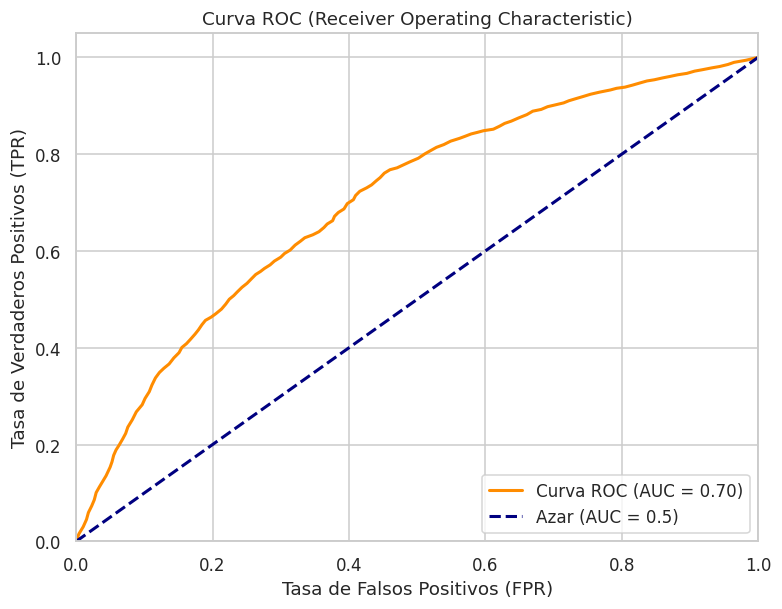


-------------------------------------
Área Bajo la Curva ROC (AUC): 0.7025


In [ ]:
# ================
# Curva ROC y AUC
# ================

# Calculamos puntos FPR/TPR y el AUC
fpr, tpr, thresholds = roc_curve(y_test_lab, y_pred_proba_lab)
roc_auc_lab = auc(fpr, tpr)

# Graficamos la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_lab:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

# Imprimimos el valor final del AUC
print("\n-------------------------------------")
print(f"Área Bajo la Curva ROC (AUC): {roc_auc_lab:.4f}")

##### Conclusión del modelo

In [ ]:
evaluar_modelo("model_pipeline_laboral", accuracy_lab, roc_auc_lab)


Modelo: model_pipeline_laboral
- Accuracy: 0.64
- AUC: 0.70
El modelo no alcanza los umbrales → No es eficiente


-------------------------------
### **4.5 Factores académicos**

Continuando se estudia el impacto que pueden tener los factores académicos —como la carrera estudiada, la presión académica, la satisfacción con los estudios y el desempeño académico— sobre los síntomas depresivos. Se realizan gráficos porcentuales y se observan las distribuciones para identificar tendencias y posibles relaciones.

#### **Análisis Inicial**

##### *Función para gráficos*

Primero creamos una función para evitar errores en el tipeo de las columnas y definiremos variables para el orden categorico correcto.

In [ ]:
# ============================================
# Funcion para elegir columnas con/sin tilde
# ============================================

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"No se encontró ninguna de estas columnas: {candidates}")
    return None

col_carrera = pick_col(df, ['Carrera'])
col_dep = pick_col(df, ['Depresión'])
col_pres_acad = pick_col(df, ['Presión_academica', 'Presion_academica', 'Presión_Académica', 'Presion_Académica'])
col_satis_ac = pick_col(df, ['Satisfacción_academica', 'Satisfaccion_academica', 'Satisfacción_Académica', 'Satisfaccion_Académica'])
col_desemp = pick_col(df, ['ID_Desempeño', 'Desempeño', 'Desempeno', 'ID_Desempeno'])

##### *Gráfico distribución por carreras*

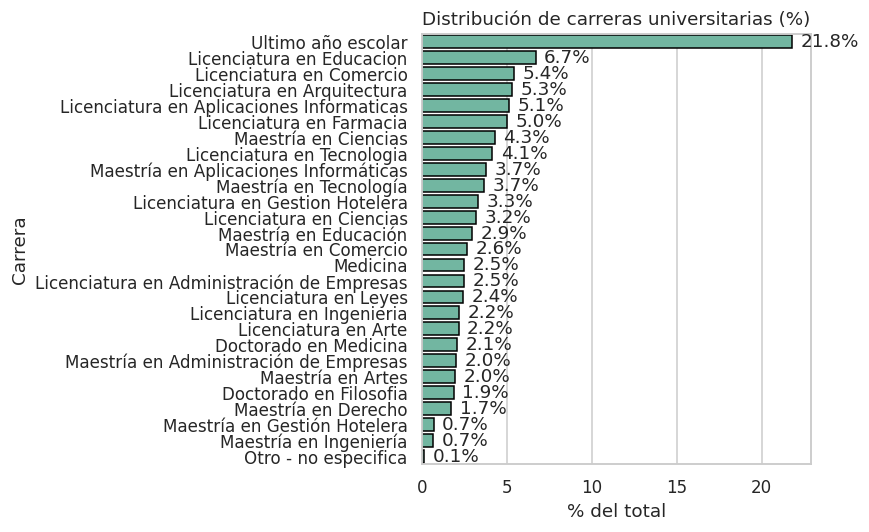

In [ ]:
# ===============================================
# Distribución de carreras (horizontal en %)
# ===============================================
carr_counts = (
    df[col_carrera]
    .astype(str)
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis('Carrera')
    .reset_index(name='%')
)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=carr_counts, y='Carrera', x='%', edgecolor='black')
ax.set_title('Distribución de carreras universitarias (%)')
ax.set_xlabel('% del total')
ax.set_ylabel('Carrera')

for p in ax.patches:
    w = p.get_width()
    ax.text(w + 0.5, p.get_y() + p.get_height()/2, f'{w:.1f}%', va='center')

plt.tight_layout()
plt.show()

##### *Gráfico porcentaje de casos por carrera*

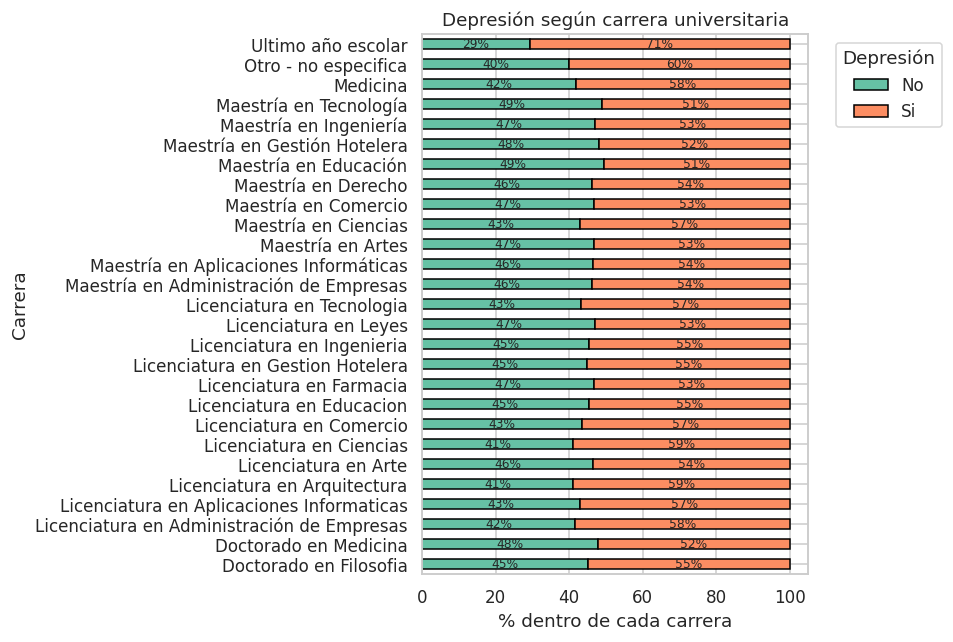


Depresión por carrera (%):


Depresión,No,Si
Carrera,,
Doctorado en Filosofia,45.2,54.8
Doctorado en Medicina,47.9,52.1
Licenciatura en Administración de Empresas,41.5,58.5
Licenciatura en Aplicaciones Informaticas,42.9,57.1
Licenciatura en Arquitectura,41.1,58.9
Licenciatura en Arte,46.5,53.5
Licenciatura en Ciencias,41.1,58.9
Licenciatura en Comercio,43.4,56.6
Licenciatura en Educacion,45.3,54.7


In [ ]:
# ==================================================
# Depresión por carrera (barras horizontales %)
# ==================================================

tab_carr = pd.crosstab(df[col_carrera].astype(str), df[col_dep].astype(str), normalize='index').mul(100)

ax = tab_carr.plot(kind='barh', stacked=True, figsize=(9,6), edgecolor='black')
ax.set_xlabel('% dentro de cada carrera')
ax.set_ylabel('Carrera')
ax.set_title('Depresión según carrera universitaria')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.legend(title="Depresión", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nDepresión por carrera (%):")
display(tab_carr.round(1))

##### *Gráfico casos por presión*

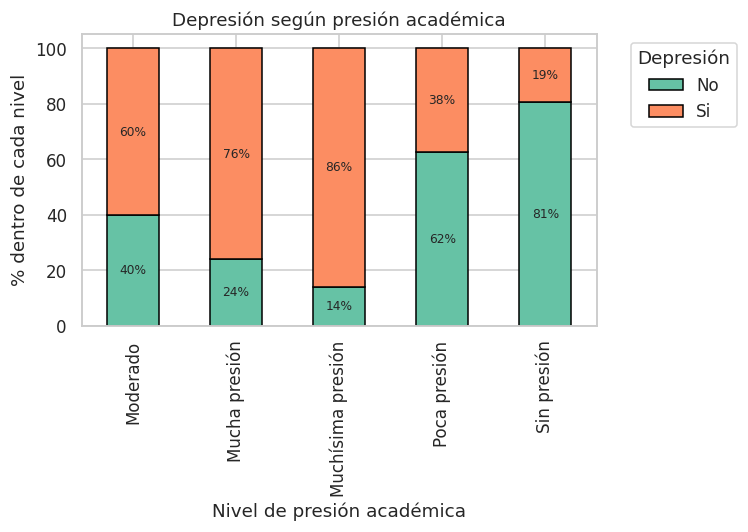


Depresión según presión académica (%):


Depresión,No,Si
Presión_academica,,
Moderado,39.8,60.2
Mucha presión,23.9,76.1
Muchísima presión,13.9,86.1
Poca presión,62.5,37.5
Sin presión,80.5,19.5


In [ ]:
# ==================================================
# Presión académica vs Depresión (apilado %)
# ==================================================
tab_presion = pd.crosstab(df[col_pres_acad].astype(str), df[col_dep].astype(str), normalize='index').mul(100)

ax = tab_presion.plot(kind='bar', stacked=True, figsize=(7,5), edgecolor='black')
ax.set_xlabel('Nivel de presión académica')
ax.set_ylabel('% dentro de cada nivel')
ax.set_title('Depresión según presión académica')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.legend(title="Depresión", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nDepresión según presión académica (%):")
display(tab_presion.round(1))

##### *Gráfico casos por satisfacción académicas*

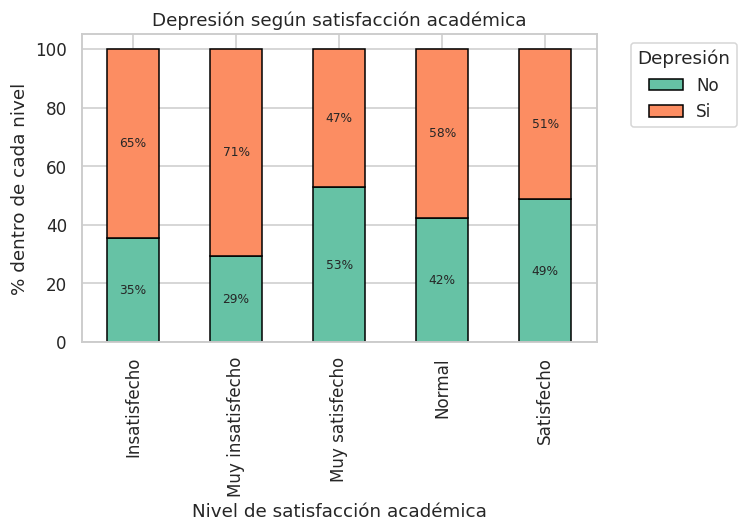


Depresión según satisfacción académica (%):


Depresión,No,Si
Satisfacción_academica,,
Insatisfecho,35.4,64.6
Muy insatisfecho,29.3,70.7
Muy satisfecho,52.8,47.2
Normal,42.4,57.6
Satisfecho,48.7,51.3


In [ ]:
# ==================================================
# 4) Satisfacción académica vs Depresión (apilado %)
# ==================================================
tab_satis = pd.crosstab(df[col_satis_ac].astype(str), df[col_dep].astype(str), normalize='index').mul(100)

ax = tab_satis.plot(kind='bar', stacked=True, figsize=(7,5), edgecolor='black')
ax.set_xlabel('Nivel de satisfacción académica')
ax.set_ylabel('% dentro de cada nivel')
ax.set_title('Depresión según satisfacción académica')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.legend(title="Depresión", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nDepresión según satisfacción académica (%):")
display(tab_satis.round(1))

##### *Gráfico casos con respecto al desempeño*


Exploración de desempeño académico:
count    27895.000000
mean         7.658137
std          1.464661
min          5.030000
25%          6.290000
50%          7.770000
75%          8.920000
max         10.000000
Name: ID_Desempeño, dtype: float64

Promedio de desempeño académico por nivel de depresión:
Depresión
No    7.620022
Si    7.685115
Name: ID_Desempeño, dtype: float64


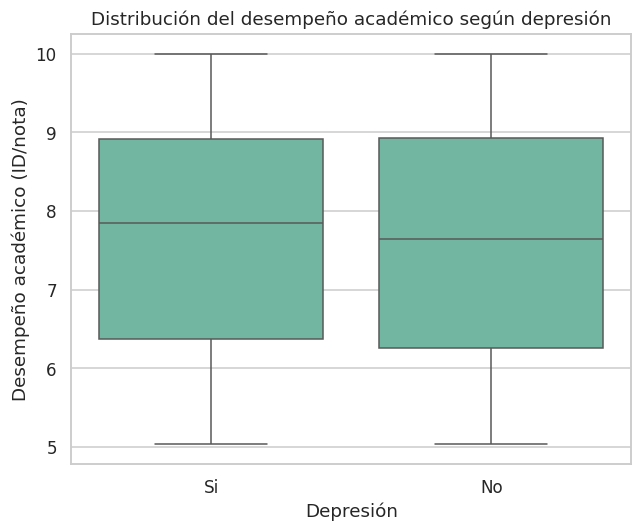

In [ ]:
# ==================================================
# Desempeño académico y depresión (promedios + box)
# ==================================================
df_desemp = df[[col_desemp, col_dep]].dropna()
print("\nExploración de desempeño académico:")
print(df_desemp[col_desemp].describe())

promedios = df_desemp.groupby(col_dep)[col_desemp].mean()
print("\nPromedio de desempeño académico por nivel de depresión:")
print(promedios)

plt.figure(figsize=(6,5))
sns.boxplot(x=col_dep, y=col_desemp, data=df_desemp)
plt.title("Distribución del desempeño académico según depresión")
plt.ylabel("Desempeño académico (ID/nota)")
plt.xlabel("Depresión")
plt.tight_layout()
plt.show()


--------------------------------------------------
##### *Interpretación de los resultados obtenidos*
--------------------------------------------------

Análisis Depresión según la carrera

* En la mayoría de las carreras universitarias el porcentaje de estudiantes con depresión supera el 50%.

* Destacan:

 * Último año escolar: 70.8% de los estudiantes reportan depresión → puede asociarse a la presión de egresar, tomar decisiones de futuro académico/laboral o cargas de proyectos finales.

 * Licenciatura en Administración de Empresas y Licenciatura en Ciencias: alrededor de 58–59% de estudiantes con depresión.

 * Medicina y Doctorados también muestran valores elevados, aunque algo menores (alrededor del 52–54%).

* Conclusión: aunque todas las carreras muestran presencia significativa de depresión, las etapas finales de formación académica y ciertas áreas exigentes (administración, ciencias, medicina) concentran los niveles más altos.

Análisis Depresión según presión académica

* El patrón es muy claro y consistente:

 * Sin presión: solo 19.5% con depresión.

 * Poca presión: 37.5%.

 * Moderada presión: 60.2%.

 * Mucha presión: 76.1%.

 * Muchísima presión: 86.1%.

* Conclusión: la relación es casi lineal: a mayor percepción de presión académica, mayor probabilidad de depresión. Esto refuerza la hipótesis de que la sobrecarga académica es un factor determinante en la salud mental.

Análisis Depresión según satisfacción académica

* Los más afectados son quienes reportan insatisfacción:

 * Muy insatisfechos: 70.7% con depresión.

 * Insatisfechos: 64.6%.

* En contraste, los estudiantes muy satisfechos presentan menor prevalencia (47.2%) y los satisfechos también algo menor (51.3%).

* Los que se declaran “normales” (ni satisfechos ni insatisfechos) se mantienen en niveles intermedios (57.6%).

* Conclusión: la satisfacción académica actúa como un factor protector, mientras que la insatisfacción incrementa significativamente la probabilidad de depresión. Esto puede vincularse a expectativas incumplidas, falta de motivación o problemas con el entorno académico.

Análisis Depresión según desempeño académico (notas)

* El boxplot y los promedios muestran que:

 * Promedio de estudiantes sin depresión: 7.62.

 * Promedio de estudiantes con depresión: 7.68.

* La diferencia es mínima y la dispersión de notas es muy similar en ambos grupos.

* No parece haber una relación clara entre rendimiento académico (medido en notas) y depresión.

* Conclusión: el desempeño académico no es un predictor fuerte de depresión, al menos en este dataset. Esto indica que los estudiantes pueden mantener buenas calificaciones a pesar de padecer depresión, lo que sugiere que el problema no está necesariamente en el rendimiento sino en la carga emocional y contextual del proceso académico.

#### **Análisis Exploratorio**

##### *Matriz de Correlación*

Se analizó la correlación entre los factores Académicos y la variable objetivo (Target) ID_Depresión.

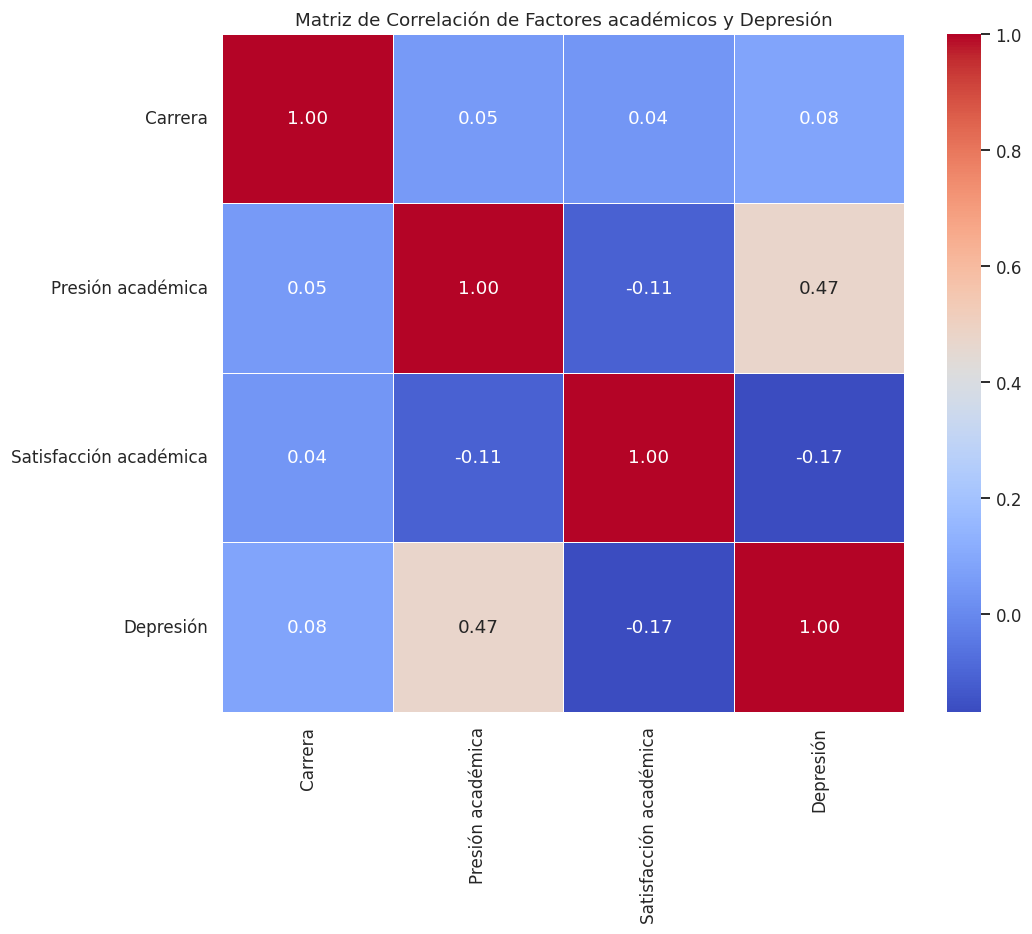


Correlaciones con la variable 'Depresión':


,Depresión
Depresión,1.000000
Presión académica,0.474919
Carrera,0.083821
Satisfacción académica,-0.167993


In [ ]:
# Diccionario de mapeo de nombres
rename_ID_acad = {
    'ID_Carrera': 'Carrera',
    'ID_Presión_Acad': 'Presión académica',
    'ID_Estres': 'Estrés',
    'ID_Satisfacción_Acad': 'Satisfacción académica',
    'ID_Depresión': 'Depresión'
}

# Seleccionar variables
corr_features_academicas = col_ID_academicas + ['ID_Depresión']
correlation_matrix_acad = df[corr_features_academicas].corr()

# Renombrar filas y columnas con nombres amigables
correlation_matrix_acad = correlation_matrix_acad.rename(index=rename_ID_acad, columns=rename_ID_acad)

# Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_acad, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Factores académicos y Depresión')
plt.show()

# Mostrar correlaciones ordenadas con el target
print("\nCorrelaciones con la variable 'Depresión':")
display(correlation_matrix_acad['Depresión'].sort_values(ascending=False))

##### *Procesamiento de datos*

In [ ]:
# Definimos las columnas que se usarán como características
features_academicos = col_ID_academicas + cat_academicas

# Variable objetivo (lo que queremos predecir: depresión Sí/No)
target = 'ID_Depresión'

# Definimos características (X) y la variable objetivo (y)
X_academicos = df[features_academicos]
y = df[target]

# Verificamos
print(col_ID_academicas)
print(cat_academicas)
print(features_academicos)
print(target)

['ID_Carrera', 'ID_Presión_Acad', 'ID_Satisfacción_Acad']
['Presión_academica', 'Satisfacción_academica', 'Carrera']
['ID_Carrera', 'ID_Presión_Acad', 'ID_Satisfacción_Acad', 'Presión_academica', 'Satisfacción_academica', 'Carrera']
ID_Depresión


In [ ]:
# ==================
# ColumnTransformer
# ==================

# Definimos un ColumnTransformer
preprocessor_academico = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_ID_academicas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_academicas)
    ],
    remainder='passthrough'
)

preprocessor_academico

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['ID_Carrera', 'ID_Presión_Acad',
                                  'ID_Satisfacción_Acad']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Presión_academica', 'Satisfacción_academica',
                                  'Carrera'])])

In [ ]:
# =========================
# División del dataset
# =========================

# Separa los datos en entrenamiento y prueba (75%-25%)
X_train_acad, X_test_acad, y_train_acad, y_test_acad = train_test_split(X_academicos, y, test_size=0.25, random_state=42, stratify=y)

# Verificamos tamaños de los conjuntos
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train_acad.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test_acad.shape}")
print(f"Tamaño del conjunto de entrenamiento (y_train): {y_train_acad.shape}")
print(f"Tamaño del conjunto de prueba (y_test): {y_test_acad.shape}")

# Mostramos la distribución de la variable objetivo en Train y Test
print("\nDistribución de la variable objetivo en Train vs Test:")
print(f"Train: \n{y_train_acad.value_counts(normalize=True)}")
print(f"Test: \n{y_test_acad.value_counts(normalize=True)}")

Tamaño del conjunto de entrenamiento (X_train): (20921, 6)
Tamaño del conjunto de prueba (X_test): (6974, 6)
Tamaño del conjunto de entrenamiento (y_train): (20921,)
Tamaño del conjunto de prueba (y_test): (6974,)

Distribución de la variable objetivo en Train vs Test:
Train: 
ID_Depresión
1    0.585536
0    0.414464
Name: proportion, dtype: float64
Test: 
ID_Depresión
1    0.585604
0    0.414396
Name: proportion, dtype: float64


##### *Construcción y Entrenamiento del Modelo (Random Forest)*

In [ ]:
# ========================================
# Construcción y entrenamiento del modelo
# ========================================

# Pipeline
model_pipeline_academico = Pipeline(steps=[
    ('preprocessor', preprocessor_academico),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Entrenamos el modelo con los datos de entrenamiento
model_pipeline_academico.fit(X_train_acad, y_train_acad)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ID_Carrera',
                                                   'ID_Presión_Acad',
                                                   'ID_Satisfacción_Acad']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Presión_academica',
                                                   'Satisfacción_academica',
                                                   'Carrera'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

##### *Evaluación del Modelo y Accuracy*

In [ ]:
# =================================
# Evaluación del modelo y Accuracy
# =================================

# Predicciones finales (clase) y probabilidades (para ROC/AUC)
y_pred_acad = model_pipeline_academico.predict(X_test_acad)
y_pred_proba_acad = model_pipeline_academico.predict_proba(X_test_acad)[:, 1]

# Accuracy global
accuracy_acad = accuracy_score(y_test_acad, y_pred_acad)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy_acad:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.7281


##### *Matriz de confusión y reporte*


--- Matriz de Confusión ---


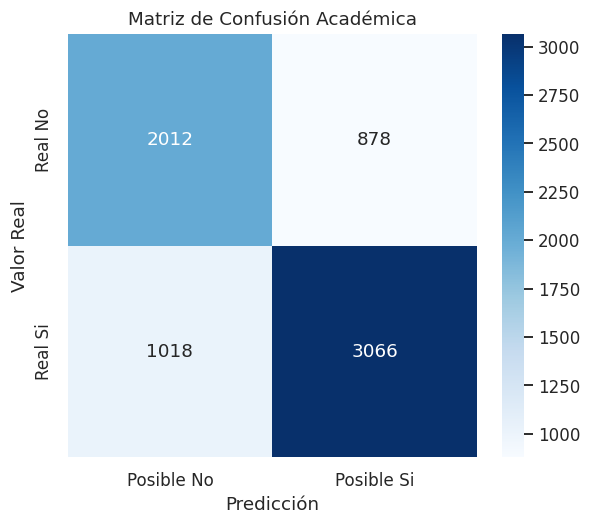

Verdaderos Negativos (TN): 2012
Falsos Positivos (FP): 878
Falsos Negativos (FN): 1018
Verdaderos Positivos (TP): 3066

--- Informe de Clasificación ---
              precision    recall  f1-score   support

Depresión No       0.66      0.70      0.68      2890
Depresión Si       0.78      0.75      0.76      4084

    accuracy                           0.73      6974
   macro avg       0.72      0.72      0.72      6974
weighted avg       0.73      0.73      0.73      6974



In [ ]:
# ====================
# Matriz de confusión
# ====================

# Gráfico de la matriz
print("\n--- Matriz de Confusión ---")
cm_acad = confusion_matrix(y_test_acad, y_pred_acad)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_acad, annot=True, fmt='d', cmap='Blues', xticklabels=['Posible No', 'Posible Si'], yticklabels=['Real No', 'Real Si'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Académica')
plt.show()

# Detalle numérico
print(f"Verdaderos Negativos (TN): {cm_acad[0,0]}")
print(f"Falsos Positivos (FP): {cm_acad[0,1]}")
print(f"Falsos Negativos (FN): {cm_acad[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_acad[1,1]}")

# Reporte de clasificación con precisión, recall y f1-score
target_names = ['Depresión No', 'Depresión Si']
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test_acad, y_pred_acad, target_names=target_names))

##### *Curva ROC y AUC*

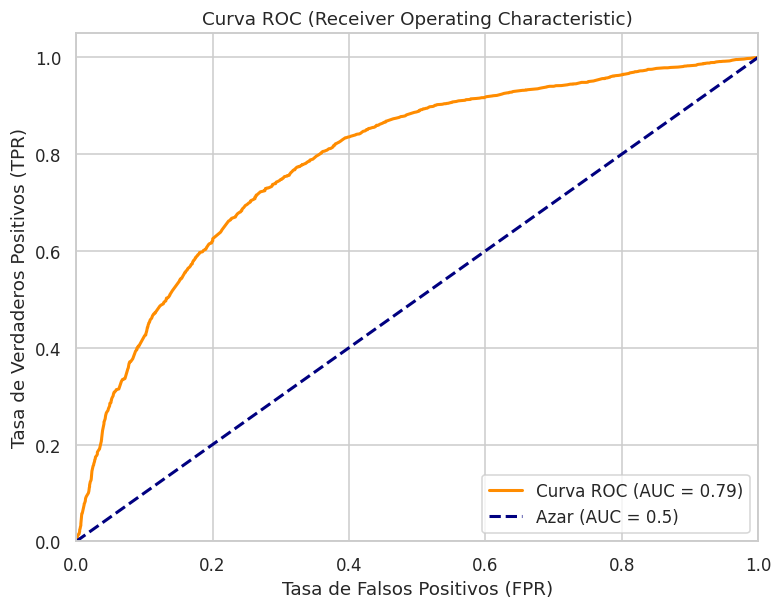


-------------------------------------
Área Bajo la Curva ROC (AUC): 0.7887


In [ ]:
# ================
# Curva ROC y AUC
# ================

# Calculamos puntos FPR/TPR y el AUC
fpr, tpr, thresholds = roc_curve(y_test_acad, y_pred_proba_acad)
roc_auc_acad = auc(fpr, tpr)

# Graficamos la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_acad:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

# Imprimimos el valor final del AUC
print("\n-------------------------------------")
print(f"Área Bajo la Curva ROC (AUC): {roc_auc_acad:.4f}")

##### Conclusión del modelo

In [ ]:
evaluar_modelo("model_pipeline_acdemico", accuracy_acad, roc_auc_acad)


Modelo: model_pipeline_acdemico
- Accuracy: 0.73
- AUC: 0.79
El modelo no alcanza los umbrales → No es eficiente


---------------------------------------------------------
### **4.6 Factores de hábitos y antecedentes familiares**

Se analizan variables vinculadas a los hábitos de vida y antecedentes personales de salud, como las horas de sueño, la alimentación, la presencia de antecedentes médicos familiares y los pensamientos suicidas. El objetivo es analizar si estos factores están relacionados con la aparición de depresión en los estudiantes estudiados.

#### **Análisis Inicial**

##### *Variables para usar*

Creación de variables que se usaran para definir los gráficos.

In [ ]:
# ================================
# Seleccionar columnas
# ================================

col_sueño = pick_col(df, ['Horas_sueño'])
col_habitos = pick_col(df, ['Alimentación'])
col_fam = pick_col(df, ['Historial_Medico_Familiar'])
col_suic = pick_col(df, ['Pensamientos_suicidas'])

##### *Gráfico Boxplot Horas de sueño*

Usamos un gráfico boxplot para observar el rango de horas de sueño que usan en su día los estudiantes en los casos positivos o negativos de depresión.

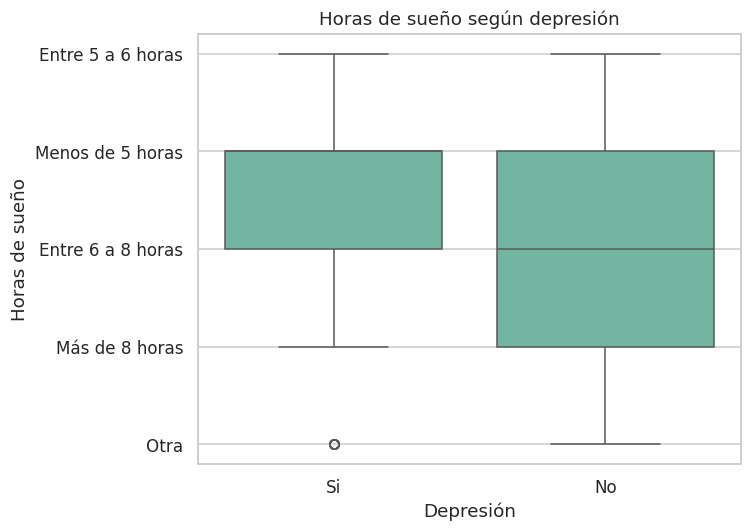

In [ ]:
# ==============================
# Horas de sueño y depresión
# ==============================
df_sueño = df[[col_sueño, col_dep]].dropna()

plt.figure(figsize=(7,5))
sns.boxplot(x=col_dep, y=col_sueño, data=df_sueño)
plt.title("Horas de sueño según depresión")
plt.xlabel("Depresión")
plt.ylabel("Horas de sueño")
plt.tight_layout()
plt.show()

##### *Gráfico casos por hábitos alimenticios*

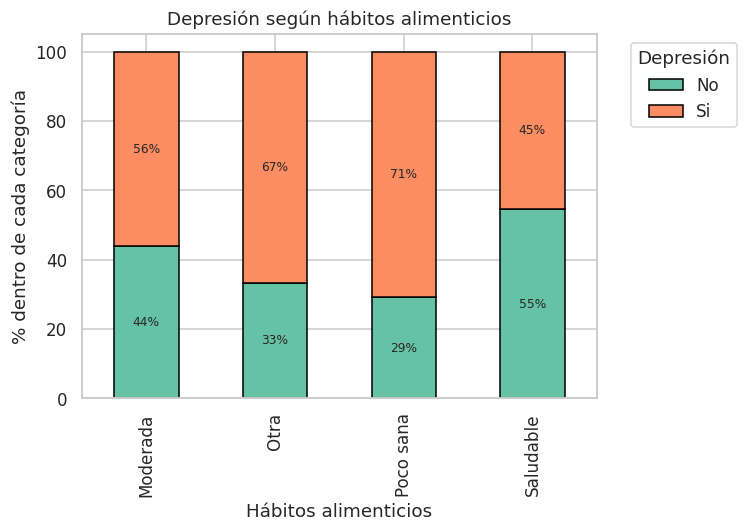


Depresión según hábitos alimenticios (%):


Depresión,No,Si
Alimentación,,
Moderada,44.0,56.0
Otra,33.3,66.7
Poco sana,29.3,70.7
Saludable,54.6,45.4


In [ ]:
# ======================================
# Hábitos alimenticios y depresión
# ======================================

tab_habitos = pd.crosstab(df[col_habitos].astype(str), df[col_dep].astype(str), normalize='index').mul(100)

ax = tab_habitos.plot(kind='bar', stacked=True, figsize=(7,5), edgecolor='black')
ax.set_title("Depresión según hábitos alimenticios")
ax.set_ylabel("% dentro de cada categoría")
ax.set_xlabel("Hábitos alimenticios")
ax.legend(title="Depresión", bbox_to_anchor=(1.05,1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\nDepresión según hábitos alimenticios (%):")
display(tab_habitos.round(1))

##### *Gráfico casos por antecedentes familiares*

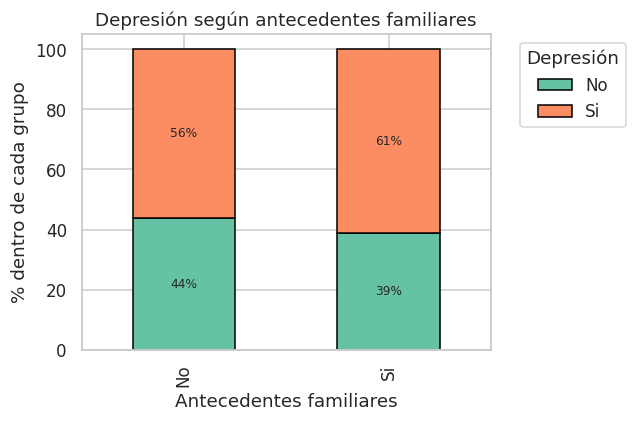


Depresión según antecedentes familiares (%):


Depresión,No,Si
Historial_Medico_Familiar,,
No,44.0,56.0
Si,38.7,61.3


In [ ]:
# ======================================
# Antecedentes familiares y depresión
# ======================================
tab_fam = pd.crosstab(df[col_fam].astype(str), df[col_dep].astype(str), normalize='index').mul(100)

ax = tab_fam.plot(kind='bar', stacked=True, figsize=(6,4), edgecolor='black')
ax.set_title("Depresión según antecedentes familiares")
ax.set_ylabel("% dentro de cada grupo")
ax.set_xlabel("Antecedentes familiares")
ax.legend(title="Depresión", bbox_to_anchor=(1.05,1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\nDepresión según antecedentes familiares (%):")
display(tab_fam.round(1))

##### *Gráfico casos por pensamientos suicidas*

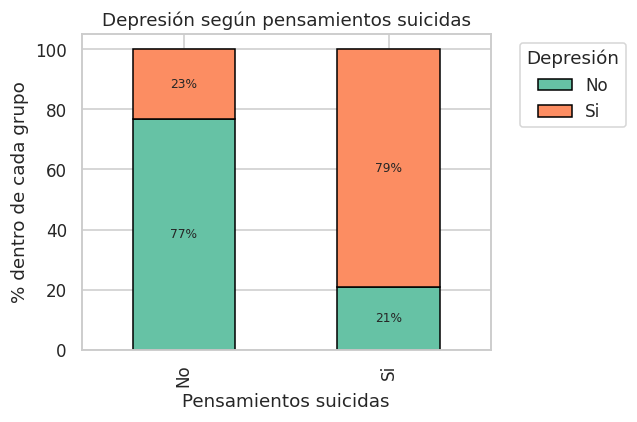


Depresión según pensamientos suicidas (%):


Depresión,No,Si
Pensamientos_suicidas,,
No,76.8,23.2
Si,20.9,79.1


In [ ]:
# ========================================
# Pensamientos suicidas y depresión
# ========================================
tab_suic = pd.crosstab(df[col_suic].astype(str), df[col_dep].astype(str), normalize='index').mul(100)

ax = tab_suic.plot(kind='bar', stacked=True, figsize=(6,4), edgecolor='black')
ax.set_title("Depresión según pensamientos suicidas")
ax.set_ylabel("% dentro de cada grupo")
ax.set_xlabel("Pensamientos suicidas")
ax.legend(title="Depresión", bbox_to_anchor=(1.05,1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\nDepresión según pensamientos suicidas (%):")
display(tab_suic.round(1))

--------------------------------------------------
##### *Interpretación de los resultados obtenidos*
--------------------------------------------------

Análisis Horas de sueño

* Los estudiantes con depresión se concentran más en los grupos con menos de 5 horas o entre 5 a 6 horas de sueño.

* En contraste, los que duermen entre 6 y 8 horas o más de 8 horas tienden a presentar menores niveles de depresión.

* El boxplot refleja que, aunque existe variabilidad en ambos grupos, los estudiantes sin depresión muestran una mayor proporción dentro de los rangos recomendados de sueño (6–8 horas).

* Conclusión: dormir pocas horas está asociado a mayor prevalencia de depresión, lo que coincide con la literatura sobre el impacto del descanso insuficiente en la salud mental.


---
Análisis Hábitos alimenticios

* Poco sana: 70.7% de depresión → el nivel más alto.

* Otra alimentación (no especificada): 66.7%.

* Moderada: 56%.

* Saludable: 45.4% → el nivel más bajo.

* Conclusión: los malos hábitos alimenticios (dieta poco sana o desorganizada) se relacionan con mayor presencia de depresión, mientras que una alimentación saludable parece actuar como factor protector.

---
Análisis Antecedentes familiares

* Con antecedentes familiares: 61.3% presentan depresión.

* Sin antecedentes: 56%.

* Conclusión: aunque la diferencia no es tan marcada como en otros factores, tener historial familiar de problemas mentales incrementa el riesgo de depresión en los estudiantes, lo que sugiere cierta predisposición hereditaria o ambiental.

---
Análisis Pensamientos suicidas

* Estudiantes sin pensamientos suicidas: solo 23.2% con depresión.

* Estudiantes con pensamientos suicidas: 79.1% con depresión.

* Conclusión: la relación es muy fuerte. La gran mayoría de quienes reportan pensamientos suicidas presentan depresión, lo que indica una asociación crítica y alerta sobre la necesidad de intervención psicológica y programas de prevención del suicidio.

#### **Análisis Exploratorio**

##### *Matriz de Correlación*

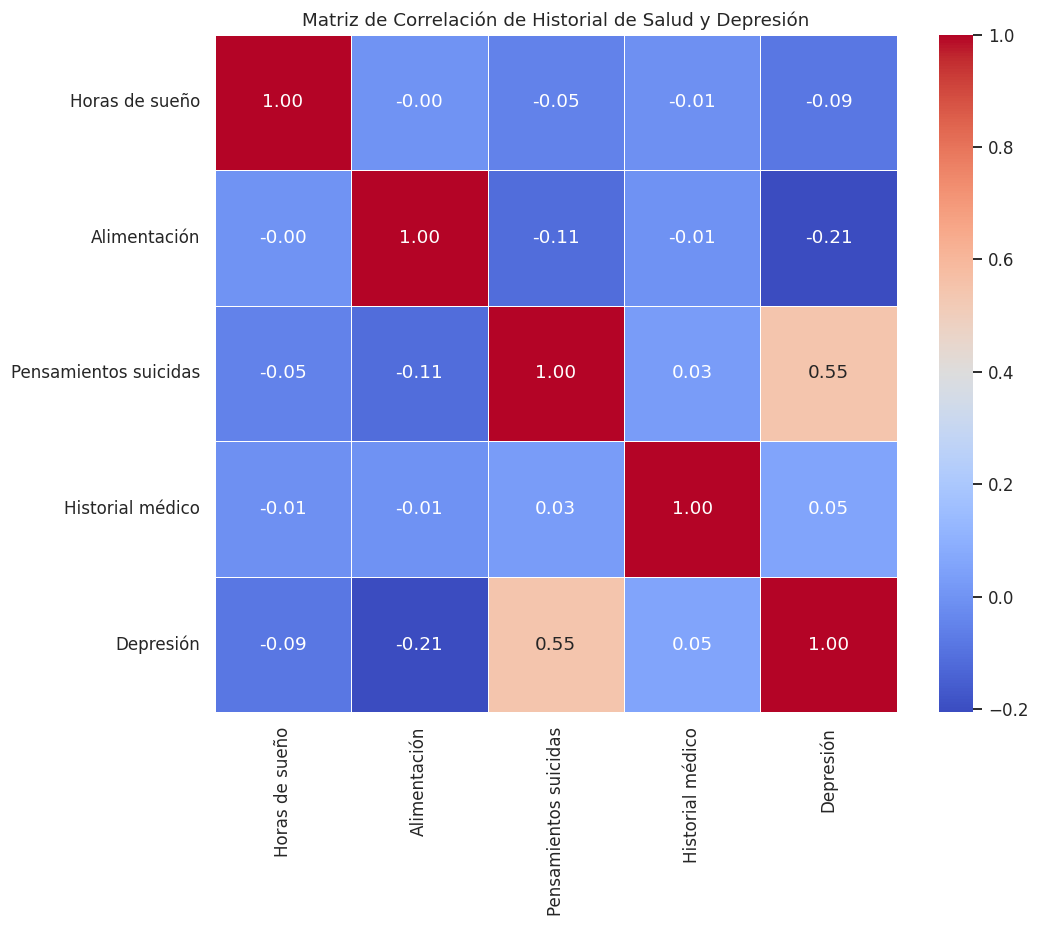


Correlaciones con la variable 'Depresión':


,Depresión
Depresión,1.000000
Pensamientos suicidas,0.546232
Historial médico,0.053336
Horas de sueño,-0.087105
Alimentación,-0.205963


In [ ]:
# Diccionario de mapeo de nombres
rename_ID_hist = {
    'ID_Carrera': 'Carrera',
    'ID_Horas_Sueño': 'Horas de sueño',
    'ID_Alimentación': 'Alimentación',
    'ID_Historial': 'Historial médico',
    'ID_Pensamientos_suicidas': 'Pensamientos suicidas',
    'ID_Depresión': 'Depresión'
}

# Seleccionar variables
corr_features_historial = col_ID_historial_salud + ['ID_Depresión']
correlation_matrix_historial = df[corr_features_historial].corr()

# Renombrar filas y columnas con nombres amigables
correlation_matrix_historial = correlation_matrix_historial.rename(index=rename_ID_hist, columns=rename_ID_hist)

# Graficar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_historial, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Historial de Salud y Depresión')
plt.show()

# Mostrar correlaciones ordenadas con el target
print("\nCorrelaciones con la variable 'Depresión':")
display(correlation_matrix_historial['Depresión'].sort_values(ascending=False))

##### *Procesamiento de datos*

In [ ]:
# Definimos las columnas que se usarán como características
features_historial = col_ID_historial_salud + cat_historial_salud

# Variable objetivo (lo que queremos predecir: depresión Sí/No)
target = 'ID_Depresión'

# Definimos características (X) y la variable objetivo (y)
X_historial = df[features_historial]
y = df[target]

# Verificamos
print(col_ID_historial_salud)
print(cat_historial_salud)
print(features_historial)
print(target)

['ID_Horas_Sueño', 'ID_Alimentación', 'ID_Pensamientos_suicidas', 'ID_Historial']
['Horas_sueño', 'Alimentación', 'Pensamientos_suicidas', 'Historial_Medico_Familiar']
['ID_Horas_Sueño', 'ID_Alimentación', 'ID_Pensamientos_suicidas', 'ID_Historial', 'Horas_sueño', 'Alimentación', 'Pensamientos_suicidas', 'Historial_Medico_Familiar']
ID_Depresión


In [ ]:
# ==================
# ColumnTransformer
# ==================

# Definimos un ColumnTransformer
preprocessor_historial = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_ID_historial_salud),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_historial_salud)
    ],
    remainder='passthrough'
)

preprocessor_historial

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['ID_Horas_Sueño', 'ID_Alimentación',
                                  'ID_Pensamientos_suicidas', 'ID_Historial']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Horas_sueño', 'Alimentación',
                                  'Pensamientos_suicidas',
                                  'Historial_Medico_Familiar'])])

In [ ]:
# =========================
# División del dataset
# =========================

# Separa los datos en entrenamiento y prueba (75%-25%)
X_train_hist, X_test_hist, y_train_hist, y_test_hist = train_test_split(X_historial, y, test_size=0.25, random_state=42, stratify=y)

# Verificamos tamaños de los conjuntos
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train_hist.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test_hist.shape}")
print(f"Tamaño del conjunto de entrenamiento (y_train): {y_train_hist.shape}")
print(f"Tamaño del conjunto de prueba (y_test): {y_test_hist.shape}")

# Mostramos la distribución de la variable objetivo en Train y Test
print("\nDistribución de la variable objetivo en Train vs Test:")
print(f"Train: \n{y_train_hist.value_counts(normalize=True)}")
print(f"Test: \n{y_test_hist.value_counts(normalize=True)}")

Tamaño del conjunto de entrenamiento (X_train): (20921, 8)
Tamaño del conjunto de prueba (X_test): (6974, 8)
Tamaño del conjunto de entrenamiento (y_train): (20921,)
Tamaño del conjunto de prueba (y_test): (6974,)

Distribución de la variable objetivo en Train vs Test:
Train: 
ID_Depresión
1    0.585536
0    0.414464
Name: proportion, dtype: float64
Test: 
ID_Depresión
1    0.585604
0    0.414396
Name: proportion, dtype: float64


##### *Construcción y Entrenamiento del Modelo (Random Forest)*

In [ ]:
# ========================================
# Construcción y entrenamiento del modelo
# ========================================

# Pipeline
model_pipeline_historial = Pipeline(steps=[
    ('preprocessor', preprocessor_historial),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Entrenamos el modelo con los datos de entrenamiento
model_pipeline_historial.fit(X_train_hist, y_train_hist)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ID_Horas_Sueño',
                                                   'ID_Alimentación',
                                                   'ID_Pensamientos_suicidas',
                                                   'ID_Historial']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Horas_sueño',
                                                   'Alimentación',
                                                   'Pensamientos_suicidas',
                                                   'Historial_Medico_Familiar'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

##### *Evalución del Modelo y Accuracy*

In [ ]:
# =================================
# Evaluación del modelo y Accuracy
# =================================

# Predicciones finales (clase) y probabilidades (para ROC/AUC)
y_pred_hist = model_pipeline_historial.predict(X_test_hist)
y_pred_proba_hist = model_pipeline_historial.predict_proba(X_test_hist)[:, 1]

# Accuracy global
accuracy_hist = accuracy_score(y_test_hist, y_pred_hist)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy_hist:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.7756


##### *Matriz de confusión y reporte*


--- Matriz de Confusión ---


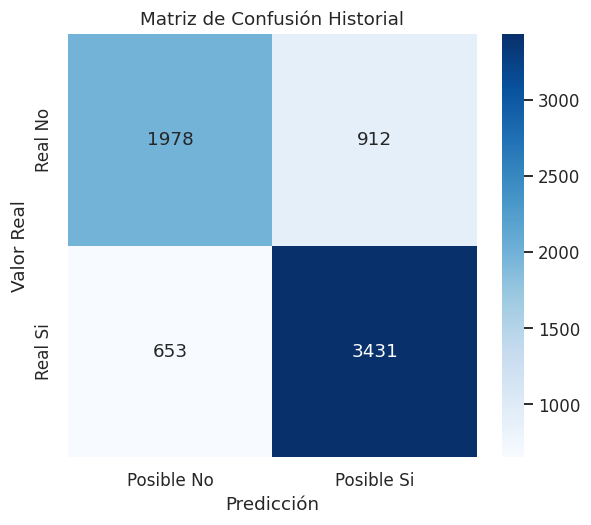

Verdaderos Negativos (TN): 1978
Falsos Positivos (FP): 912
Falsos Negativos (FN): 653
Verdaderos Positivos (TP): 3431

--- Informe de Clasificación ---
              precision    recall  f1-score   support

Depresión No       0.75      0.68      0.72      2890
Depresión Si       0.79      0.84      0.81      4084

    accuracy                           0.78      6974
   macro avg       0.77      0.76      0.77      6974
weighted avg       0.77      0.78      0.77      6974



In [ ]:
# ====================
# Matriz de confusión
# ====================

# Gráfico de la matriz
print("\n--- Matriz de Confusión ---")
cm_hist = confusion_matrix(y_test_hist, y_pred_hist)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hist, annot=True, fmt='d', cmap='Blues', xticklabels=['Posible No', 'Posible Si'], yticklabels=['Real No', 'Real Si'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Historial')
plt.show()

# Detalle numérico
print(f"Verdaderos Negativos (TN): {cm_hist[0,0]}")
print(f"Falsos Positivos (FP): {cm_hist[0,1]}")
print(f"Falsos Negativos (FN): {cm_hist[1,0]}")
print(f"Verdaderos Positivos (TP): {cm_hist[1,1]}")

# Reporte de clasificación con precisión, recall y f1-score
target_names = ['Depresión No', 'Depresión Si']
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test_hist, y_pred_hist, target_names=target_names))

##### *Curva ROC y AUC*

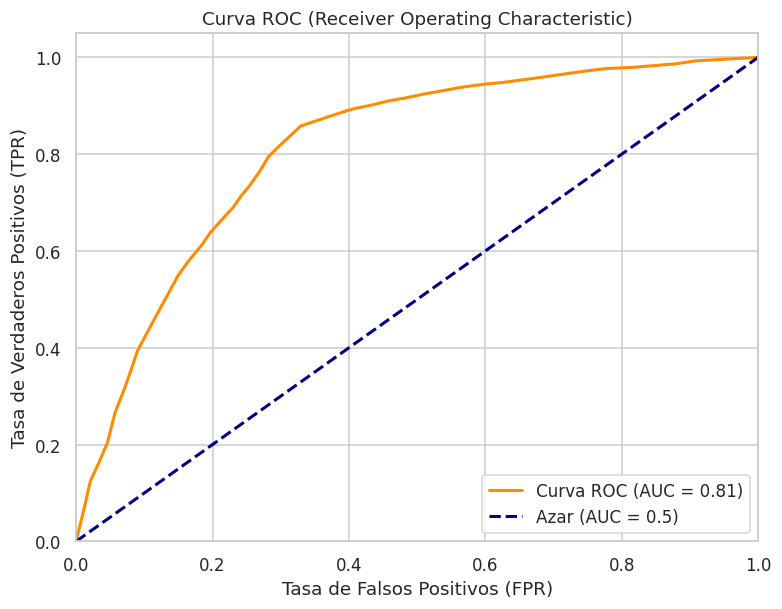


-------------------------------------
Área Bajo la Curva ROC (AUC): 0.8109


In [ ]:
# ================
# Curva ROC y AUC
# ================

# Calculamos puntos FPR/TPR y el AUC
fpr, tpr, thresholds = roc_curve(y_test_hist, y_pred_proba_hist)
roc_auc_hist = auc(fpr, tpr)

# Graficamos la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_hist:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

# Imprimimos el valor final del AUC
print("\n-------------------------------------")
print(f"Área Bajo la Curva ROC (AUC): {roc_auc_hist:.4f}")

##### Conclusión del modelo

In [ ]:
evaluar_modelo("model_pipeline_historial", accuracy_hist, roc_auc_hist)


Modelo: model_pipeline_historial
- Accuracy: 0.78
- AUC: 0.81
El modelo predice por encima de los umbrales → Eficiente


-----------------------------------------------
### **4.7 Factores Generales**

En este apartado se analizan variables de carácter amplio que engloban aspectos demográficos, académicos, laborales y de salud, con el fin de identificar patrones globales que puedan influir en la presencia de depresión en los estudiantes. El objetivo es evaluar un modelo integral que combine todos los factores disponibles, permitiendo comparar su desempeño frente a los análisis específicos por bloques y determinar si una visión más holística ofrece mejores resultados predictivos.

#### *Procesamiento de datos*

In [ ]:
# Definimos las columnas que se usarán como características
features = columnas_numericas + columnas_categoricas

# Variable objetivo (lo que queremos predecir: depresión Sí/No)
target = 'ID_Depresión'

# Definir las características (X) y la variable objetivo (y)
X = df[features]
y = df[target]

# Verificamos
print(columnas_numericas)
print(columnas_categoricas)
print(features)
print(target)

['ID_Genero', 'ID_Rango', 'ID_Presión_Lab', 'ID_Satisfacción_Lab', 'ID_Estres', 'ID_Carrera', 'ID_Presión_Acad', 'ID_Satisfacción_Acad', 'ID_Horas_Sueño', 'ID_Alimentación', 'ID_Pensamientos_suicidas', 'ID_Historial']
['Genero', 'Rango_etario', 'Presión_academica', 'Presión_laboral', 'Satisfacción_academica', 'Satisfacción_laboral', 'Horas_sueño', 'Alimentación', 'Carrera', 'Pensamientos_suicidas', 'Estrés_financiero', 'Historial_Medico_Familiar']
['ID_Genero', 'ID_Rango', 'ID_Presión_Lab', 'ID_Satisfacción_Lab', 'ID_Estres', 'ID_Carrera', 'ID_Presión_Acad', 'ID_Satisfacción_Acad', 'ID_Horas_Sueño', 'ID_Alimentación', 'ID_Pensamientos_suicidas', 'ID_Historial', 'Genero', 'Rango_etario', 'Presión_academica', 'Presión_laboral', 'Satisfacción_academica', 'Satisfacción_laboral', 'Horas_sueño', 'Alimentación', 'Carrera', 'Pensamientos_suicidas', 'Estrés_financiero', 'Historial_Medico_Familiar']
ID_Depresión


In [ ]:
# ==================
# ColumnTransformer
# ==================

# Definimos un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ],
    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['ID_Genero', 'ID_Rango', 'ID_Presión_Lab',
                                  'ID_Satisfacción_Lab', 'ID_Estres',
                                  'ID_Carrera', 'ID_Presión_Acad',
                                  'ID_Satisfacción_Acad', 'ID_Horas_Sueño',
                                  'ID_Alimentación', 'ID_Pensamientos_suicidas',
                                  'ID_Historial']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Genero', 'Rango_etario', 'Presión_academica',
                                  'Presión_laboral', 'Satisfacción_academica',
                                  'Satisfacción_laboral', 'Horas_sueño',
                                  'Alimentación', 'Carrera',
                                  'Pensamientos_suicidas', 'Estrés_financiero',
                                  'Historial_Medico_Familiar'])])

In [ ]:
# =========================
# División del dataset
# =========================

# Separa los datos en entrenamiento y prueba (75%-25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Verificamos tamaños de los conjuntos
print(f"Tamaño del conjunto de entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de prueba (X_test): {X_test.shape}")
print(f"Tamaño del conjunto de entrenamiento (y_train): {y_train.shape}")
print(f"Tamaño del conjunto de prueba (y_test): {y_test.shape}")

# Mostramos la distribución de la variable objetivo en Train y Test
print("\nDistribución de la variable objetivo en Train vs Test:")
print(f"Train: \n{y_train.value_counts(normalize=True)}")
print(f"Test: \n{y_test.value_counts(normalize=True)}")

Tamaño del conjunto de entrenamiento (X_train): (20921, 24)
Tamaño del conjunto de prueba (X_test): (6974, 24)
Tamaño del conjunto de entrenamiento (y_train): (20921,)
Tamaño del conjunto de prueba (y_test): (6974,)

Distribución de la variable objetivo en Train vs Test:
Train: 
ID_Depresión
1    0.585536
0    0.414464
Name: proportion, dtype: float64
Test: 
ID_Depresión
1    0.585604
0    0.414396
Name: proportion, dtype: float64


#### *Construcción y Entrenamiento del Modelo (Random Forest)*

In [ ]:
# ========================================
# Construcción y entrenamiento del modelo
# ========================================

# Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Entrenamos el modelo con los datos de entrenamiento
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['ID_Genero', 'ID_Rango',
                                                   'ID_Presión_Lab',
                                                   'ID_Satisfacción_Lab',
                                                   'ID_Estres', 'ID_Carrera',
                                                   'ID_Presión_Acad',
                                                   'ID_Satisfacción_Acad',
                                                   'ID_Horas_Sueño',
                                                   'ID_Alimentación',
                                                   'ID_Pensamientos_suicidas',
                                                   'ID_Historial']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Genero', 'Rango_etario',
                                                   'Presión_academica',
                                                   'Presión_laboral',
                                                   'Satisfacción_academica',
                                                   'Satisfacción_laboral',
                                                   'Horas_sueño',
                                                   'Alimentación', 'Carrera',
                                                   'Pensamientos_suicidas',
                                                   'Estrés_financiero',
                                                   'Historial_Medico_Familiar'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

#### *Evaluación del Modelo y Accuracy*

In [ ]:
# =================================
# Evaluación del modelo y Accuracy
# =================================

# Predicciones finales (clase) y probabilidades (para ROC/AUC)
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

# Accuracy global
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Accuracy Score ---")
print(f"Accuracy en el conjunto de prueba: {accuracy:.4f}")

--- Accuracy Score ---
Accuracy en el conjunto de prueba: 0.8327


#### *Matriz de confusión y reporte*


--- Matriz de Confusión ---


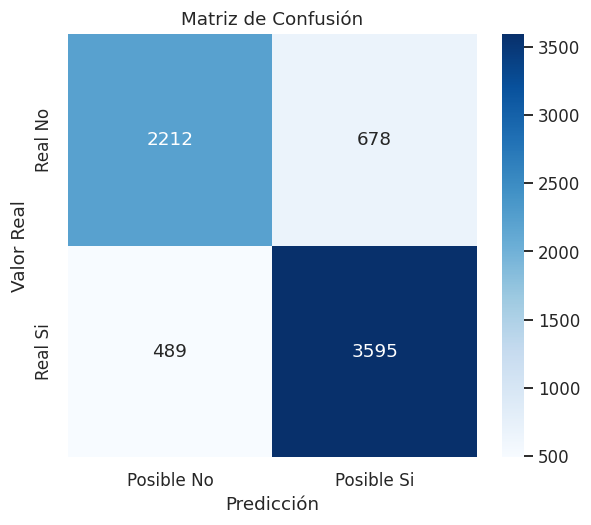

Verdaderos Negativos (TN): 2212
Falsos Positivos (FP): 678
Falsos Negativos (FN): 489
Verdaderos Positivos (TP): 3595

--- Informe de Clasificación ---
              precision    recall  f1-score   support

Depresión No       0.82      0.77      0.79      2890
Depresión Si       0.84      0.88      0.86      4084

    accuracy                           0.83      6974
   macro avg       0.83      0.82      0.83      6974
weighted avg       0.83      0.83      0.83      6974



In [ ]:
# ====================
# Matriz de confusión
# ====================

# Gráfico de la matriz
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posible No', 'Posible Si'], yticklabels=['Real No', 'Real Si'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Detalle numérico
print(f"Verdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

# Reporte de clasificación con precisión, recall y f1-score
target_names = ['Depresión No', 'Depresión Si']
print("\n--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=target_names))

#### *Curva ROC y AUC*

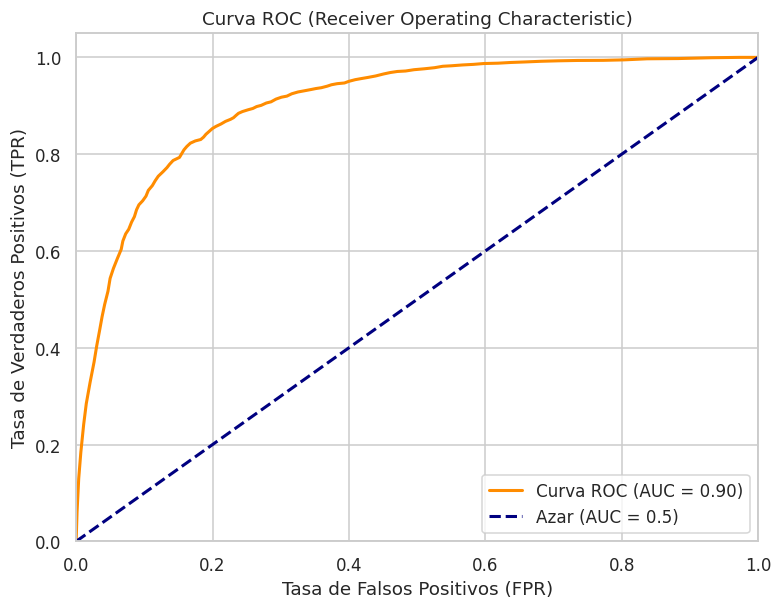


-------------------------------------
Área Bajo la Curva ROC (AUC): 0.9032


In [ ]:
# ================
# Curva ROC y AUC
# ================

# Calculamos puntos FPR/TPR y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Graficamos la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC (Receiver Operating Characteristic)')
plt.legend(loc="lower right")
plt.show()

# Imprimimos el valor final del AUC
print("\n-------------------------------------")
print(f"Área Bajo la Curva ROC (AUC): {roc_auc:.4f}")

#### Conclusión del modelo

In [ ]:
evaluar_modelo("model_pipeline", accuracy, roc_auc)


Modelo: model_pipeline
- Accuracy: 0.83
- AUC: 0.90
El modelo predice por encima de los umbrales → Eficiente


#### *Análisis de Importancia de Características*

In [ ]:
# Se obtiene el clasificador Random Forest que está dentro del pipeline
rf_classifier = model_pipeline.named_steps['classifier']

# Importancias calculadas por el Random Forest (cuánto aporta cada variable a las predicciones)
importances = rf_classifier.feature_importances_

In [ ]:
# =====================================================
# Recuperar nombres de variables tras el OneHotEncoder
# =====================================================

# Se accede al OneHotEncoder usado en el preprocesamiento
ohe_transformer = model_pipeline.named_steps['preprocessor'].transformers_[1][1]

# Se obtiene la lista de categorías que el OneHotEncoder generó para cada variable categórica
ohe_categories = ohe_transformer.categories_

ohe_categories

[array(['F', 'M'], dtype=object),
 array(['Entre 20 a 29 años', 'Entre 30 a 39 años', 'Entre 40 a 49 años',
        'Entre 50 a 59 años', 'Menor a 20 años'], dtype=object),
 array(['Moderado', 'Mucha presión', 'Muchísima presión', 'Poca presión',
        'Sin presión'], dtype=object),
 array(['Moderado', 'Mucha presión', 'Muchísima presión', 'Poca presión',
        'Sin presión'], dtype=object),
 array(['Insatisfecho', 'Muy insatisfecho', 'Muy satisfecho', 'Normal',
        'Satisfecho'], dtype=object),
 array(['Insatisfecho', 'Muy insatisfecho', 'Muy satisfecho', 'Normal',
        'Satisfecho'], dtype=object),
 array(['Entre 5 a 6 horas', 'Entre 6 a 8 horas', 'Menos de 5 horas',
        'Más de 8 horas', 'Otra'], dtype=object),
 array(['Moderada', 'Otra', 'Poco sana', 'Saludable'], dtype=object),
 array(['Doctorado en Filosofia', 'Doctorado en Medicina',
        'Licenciatura en Administración de Empresas',
        'Licenciatura en Aplicaciones Informaticas',
        'Licenciatura en 

In [ ]:
# Construimos los nombres de las variables ya transformadas
ohe_feature_names = []
for i, col in enumerate(columnas_categoricas):
    for category in ohe_categories[i]:
        ohe_feature_names.append(f"{col}_{category}")

ohe_feature_names

['Genero_F',
 'Genero_M',
 'Rango_etario_Entre 20 a 29 años',
 'Rango_etario_Entre 30 a 39 años',
 'Rango_etario_Entre 40 a 49 años',
 'Rango_etario_Entre 50 a 59 años',
 'Rango_etario_Menor a 20 años',
 'Presión_academica_Moderado',
 'Presión_academica_Mucha presión',
 'Presión_academica_Muchísima presión',
 'Presión_academica_Poca presión',
 'Presión_academica_Sin presión',
 'Presión_laboral_Moderado',
 'Presión_laboral_Mucha presión',
 'Presión_laboral_Muchísima presión',
 'Presión_laboral_Poca presión',
 'Presión_laboral_Sin presión',
 'Satisfacción_academica_Insatisfecho',
 'Satisfacción_academica_Muy insatisfecho',
 'Satisfacción_academica_Muy satisfecho',
 'Satisfacción_academica_Normal',
 'Satisfacción_academica_Satisfecho',
 'Satisfacción_laboral_Insatisfecho',
 'Satisfacción_laboral_Muy insatisfecho',
 'Satisfacción_laboral_Muy satisfecho',
 'Satisfacción_laboral_Normal',
 'Satisfacción_laboral_Satisfecho',
 'Horas_sueño_Entre 5 a 6 horas',
 'Horas_sueño_Entre 6 a 8 horas',
 

Importancia de las características según Random Forest:
                                Feature  Importance
10             ID_Pensamientos_suicidas    0.087896
76             Pensamientos_suicidas_Si    0.080657
6                       ID_Presión_Acad    0.077633
75             Pensamientos_suicidas_No    0.073551
4                             ID_Estres    0.047710
5                            ID_Carrera    0.037612
23        Presión_academica_Sin presión    0.032137
21  Presión_academica_Muchísima presión    0.025063
7                  ID_Satisfacción_Acad    0.024099
3                   ID_Satisfacción_Lab    0.022246
2                        ID_Presión_Lab    0.022127
78     Estrés_financiero_Estrés extremo    0.021172
8                        ID_Horas_Sueño    0.019200
9                       ID_Alimentación    0.016698
80     Estrés_financiero_Nada estresado    0.015093


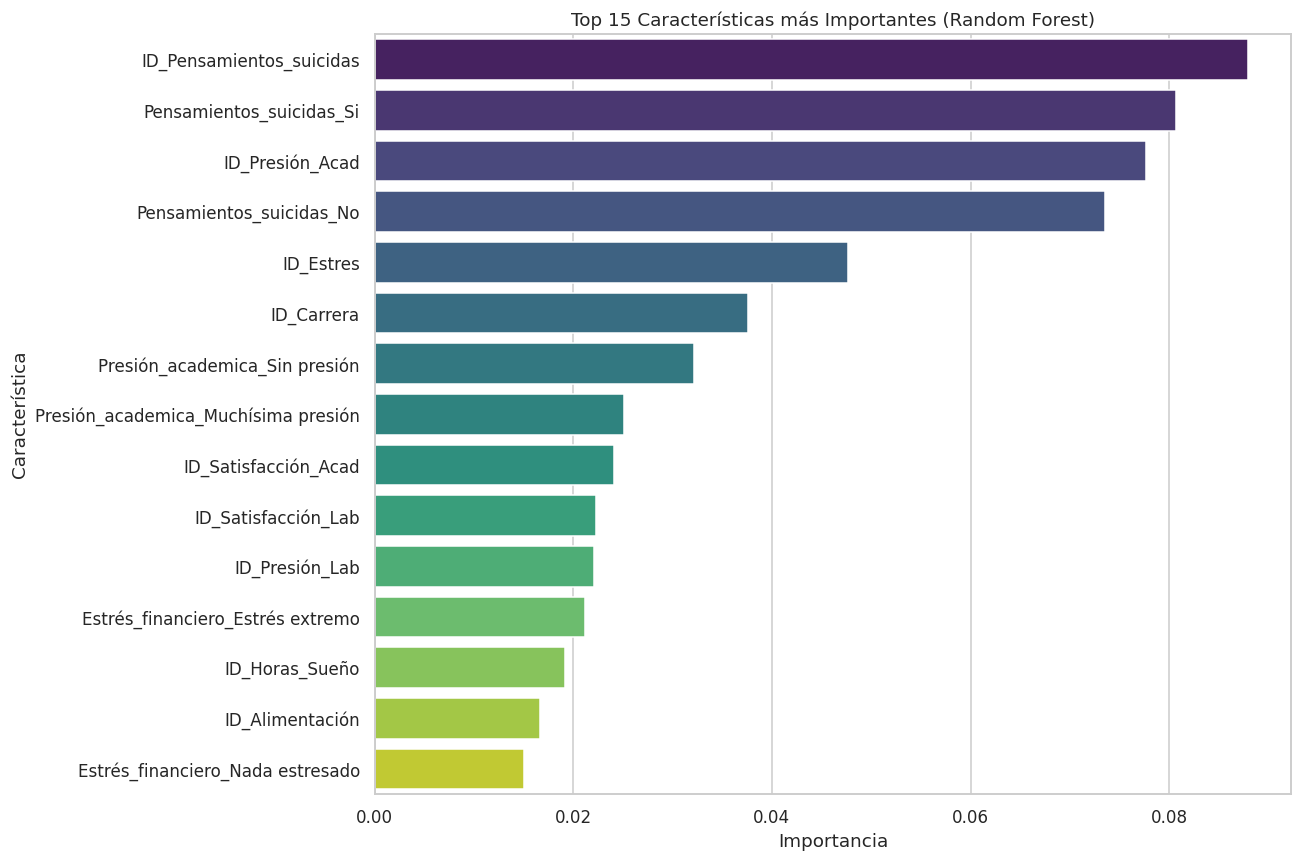

In [ ]:
# Lista final de features = numéricas originales + categóricas codificadas
final_feature_names = columnas_numericas + ohe_feature_names

# =================================
# Crear DataFrame con Importancias
# =================================

# Verificamos que la cantidad de importancias coincida con la cantidad de variables procesadas
if len(importances) == len(final_feature_names):
    feature_importance_df = pd.DataFrame({'Feature': final_feature_names, 'Importance': importances})

    # Ordenamos de mayor a menor importancia
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Mostramos las 15 variables más importantes
    print("Importancia de las características según Random Forest:")
    print(feature_importance_df.head(15))

    # Graficar la importancia de las características
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis', hue='Feature')
    plt.title('Top 15 Características más Importantes (Random Forest)')
    plt.xlabel('Importancia')
    plt.ylabel('Característica')
    plt.tight_layout()
    plt.show()

-----------------------------------------------
## **5. Conclusiones**

---
### **5.1 Casos en el tiempo**

#### *Conclusión mensual*
Se observa una tendencia constante de casos positivos mes a mes, sin grandes picos ni caídas. La cantidad de positivos es sistemáticamente mayor que la de negativos, lo que indicaría una presencia sostenida de depresión en el transcurso del año con poca estacionalidad mensual marcada.

#### *Conclusión trimestral*
La cantidad de casos positivos se mantiene alta a lo largo de todos los trimestres con pequeñas variaciones. No se observa una disminución hacia fin de año ni un pico estacional. Esto indica una tendencia estable y sostenida de depresión en la población a lo largo del año completo.

#### *Conclusión general sobre la evolución temporal*

No hay estacionalidad marcada: ni mensual ni trimestral hay picos abruptos, sino una constancia.
Casos positivos duplican o superan claramente a los negativos en promedio.
La depresión parece persistente en el tiempo, sin meses de mejoría destacable, lo cual puede reflejar un problema sostenido en la población estudiantil.

---
### **5.2 Diferencias demográficas**

#### *Conclusión*


No hay diferencia significativa en la edad promedio entre hombres y mujeres.

El porcentaje de depresión es ligeramente mayor en mujeres (media 0.5845 vs 0.5863 en hombres parece igual, pero cuidado: puede haber error de redondeo, habría que ver número real). En general, ambos géneros tienen una prevalencia alta de depresión (alrededor del 58% de la muestra en ambos).

Porcientos altos de depresión en ambos géneros respaldan la conclusión de que es un problema generalizado en esta población estudiantil, sin una brecha gigante, aunque los gráficos mostraban ligeras diferencias en ciertos grupos etarios.

#### *Conclusiones del modelo con variables demográficas*

Capacidad predictiva limitada:
El modelo de Random Forest entrenado únicamente con variables demográficas (Género y Rango etario) obtuvo un desempeño moderado, con un Accuracy de 63.7% y un AUC de 0.61, apenas por encima del valor esperado por azar (0.50). Esto refleja que la capacidad predictiva de las variables demográficas por sí solas es limitada.

Sensibilidad elevada, especificidad reducida:
El modelo mostró un recall del 82% para la clase “Depresión Sí”, lo que significa que es relativamente bueno identificando estudiantes con depresión. Sin embargo, la precisión para la clase “Depresión No” fue baja (37%), generando un alto número de falsos positivos.

Desbalance en el desempeño por clase:
Si bien se utilizó la opción de balanceo en el Random Forest, los resultados evidencian que el modelo tiende a sobrepredecir la presencia de depresión, lo que disminuye la capacidad de identificar correctamente a quienes no presentan síntomas.

Aporte de las variables demográficas:
El análisis de correlación mostró que el rango etario presenta cierta relación negativa con la depresión (-0.21), mientras que el género prácticamente no aporta señal predictiva. Esto coincide con el bajo poder discriminante observado en las métricas globales del modelo.

Implicancia para el proyecto:
Estos resultados sugieren que las variables demográficas son insuficientes para explicar y predecir adecuadamente la depresión en estudiantes.


---
### **5.3 Factores Laborales**

#### *Conclusión*

Entre los factores laborales analizados, el estrés financiero resulta ser el que muestra la relación más clara con la depresión: los estudiantes con estrés extremo presentan más del 80% de casos depresivos, mientras que aquellos con “nada de estrés” tienen solo un 31,9%. En cambio, la variable presión laboral muestra una leve tendencia creciente, pero los porcentajes de depresión se mantienen relativamente altos en todos los niveles, por lo cual la relación es moderada. Finalmente, la satisfacción laboral prácticamente no presenta diferencias entre niveles, lo que indica que este factor no se comporta como determinante en esta muestra. En síntesis, el estrés financiero aparece como el factor clave dentro de este bloque laboral, mientras que la presión y satisfacción laboral parecen tener menos impacto sobre la presencia de depresión.

#### *Conclusiones del modelo con variables laborales*

Desempeño moderado del modelo:
El Random Forest entrenado con variables laborales alcanzó un Accuracy del 66% y un AUC de 0.68, mostrando una mejora respecto al modelo basado solo en variables demográficas. Esto indica que los factores laborales aportan mayor señal predictiva, aunque todavía no explican completamente la presencia de depresión.

Mejor equilibrio entre sensibilidad y especificidad:
El modelo logró un recall del 74% para la clase “Depresión Sí”, reduciendo el sesgo hacia falsos positivos que se observaba en las variables demográficas. Al mismo tiempo, la precisión para “Depresión No” mejoró, aunque sigue siendo limitada, lo que refleja un desempeño más equilibrado entre ambas clases.

Aporte diferencial de las variables laborales:
Del análisis de importancia de variables se desprende que la satisfacción laboral y el nivel de estrés en el trabajo son los factores con mayor poder predictivo. En contraste, la carga horaria semanal tuvo menor relevancia, lo que sugiere que la calidad de la experiencia laboral pesa más que la cantidad de horas trabajadas.

Implicancias para el proyecto:
Estos hallazgos muestran que los factores laborales tienen un rol significativo en la predicción de depresión estudiantil, posiblemente al incidir en el nivel de estrés, motivación y bienestar general de los estudiantes. Sin embargo, su capacidad explicativa sigue siendo parcial, lo que refuerza la necesidad de integrar dimensiones adicionales (académicas, de salud y personales) para mejorar la robustez del modelo.

---
### **5.4 Factores Académicos**

#### *Conclusión*

El análisis de los factores académicos asociados a la depresión en estudiantes de la India muestra que la problemática trasciende el rendimiento medido en términos de calificaciones y se concentra principalmente en la percepción y experiencia del entorno académico. Si bien la mayoría de las carreras presentan prevalencias elevadas de depresión, se observan mayores niveles en los estudiantes que transitan el último año escolar y en ciertas áreas de estudio altamente demandantes, como ciencias, administración o medicina.

La presión académica emerge como el factor más determinante: los resultados evidencian un incremento casi lineal de los síntomas depresivos a medida que se intensifica la percepción de carga académica, alcanzando niveles superiores al 80% entre quienes reportan “muchísima presión”. De manera complementaria, la satisfacción académica desempeña un rol protector, ya que los estudiantes satisfechos o muy satisfechos exhiben menores niveles de depresión en comparación con aquellos insatisfechos o muy insatisfechos.

Por otro lado, el desempeño académico (notas) no muestra una diferencia significativa entre estudiantes con y sin depresión, lo que indica que esta enfermedad no necesariamente se refleja en el rendimiento cuantitativo, sino que afecta principalmente al bienestar emocional y psicológico del alumnado.

En síntesis, los hallazgos sugieren que la depresión en estudiantes está más relacionada con la presión y la percepción de satisfacción con el proceso formativo que con los resultados académicos objetivos. Este hecho refuerza la necesidad de implementar políticas y programas institucionales orientados a reducir la sobrecarga académica, promover entornos de aprendizaje más saludables y brindar apoyo psicológico que permita mitigar los efectos negativos de la presión universitaria en la salud mental.

#### *Conclusiones del modelo con variables académicas*

Mejor capacidad predictiva que dimensiones anteriores:
El modelo de Random Forest entrenado con variables académicas alcanzó un Accuracy del 72.8% y un AUC de 0.79, lo que representa un salto importante frente a los modelos basados en factores demográficos y laborales. Esto muestra que las características académicas contienen una señal predictiva más fuerte respecto a la presencia de depresión.

Balance entre sensibilidad y precisión:
El recall para la clase “Depresión Sí” fue del 75%, mientras que la precisión alcanzó un 78%, logrando un buen equilibrio entre identificar correctamente a quienes presentan depresión y reducir los falsos positivos. Asimismo, la clase “Depresión No” obtuvo un desempeño más sólido (66% de precisión y 70% de recall) que en los modelos anteriores, evidenciando menor sesgo hacia una clase específica.

Variables con mayor aporte:
La correlación indicó que la presión académica (0.47) es el predictor más fuerte, confirmando que altos niveles de exigencia académica están asociados con mayor probabilidad de depresión. En contraste, la satisfacción académica mostró una correlación negativa (-0.17), sugiriendo un efecto protector. La carrera estudiada tuvo un aporte bajo (0.08), lo que refleja menor peso en la predicción.

Implicancias para el proyecto:
Los factores académicos demuestran ser determinantes en el riesgo de depresión estudiantil, ya que explican mejor los patrones que los factores demográficos o laborales. Esto resalta la importancia de implementar programas institucionales orientados a la gestión del estrés académico, fortalecimiento del bienestar estudiantil y promoción de la satisfacción con la carrera elegida.

---
### **5.5 Factores de hábitos y antecedentes familiares**

#### *Conclusión*

El análisis de los factores vinculados a los hábitos de vida y antecedentes familiares evidencia una clara asociación entre conductas poco saludables y la presencia de depresión en estudiantes. Los resultados muestran que la falta de horas adecuadas de sueño y una alimentación poco sana incrementan significativamente la probabilidad de síntomas depresivos, mientras que el descanso suficiente y una dieta equilibrada funcionan como factores protectores.

En cuanto a los antecedentes familiares, si bien la diferencia porcentual no es tan marcada, se observa que aquellos estudiantes con historial médico familiar relacionado a enfermedades mentales presentan una mayor prevalencia de depresión, lo que sugiere la existencia de componentes hereditarios o contextuales que aumentan la vulnerabilidad.

Finalmente, los pensamientos suicidas se consolidan como el factor de mayor gravedad, dado que más del 79% de los estudiantes que los reportan también presentan depresión. Esta relación estrecha pone en evidencia la urgencia de implementar estrategias de prevención y acompañamiento psicológico, ya que la depresión en estos casos se vincula con un riesgo elevado de conductas autolesivas.

En conjunto, estos hallazgos refuerzan la idea de que la depresión estudiantil no solo está determinada por factores académicos o de presión institucional, sino también por hábitos de vida, predisposiciones familiares y, en casos extremos, pensamientos suicidas, los cuales requieren una atención prioritaria desde el ámbito educativo y sanitario.

#### *Conclusiones del modelo con factores de historial de salud*

Buen poder predictivo:
El modelo entrenado con variables de historial de salud obtuvo un Accuracy de 77.6% y un AUC de 0.81, mostrando un desempeño sólido y claramente superior al azar (0.50). Esto indica que las características de salud personal son relevantes para predecir la depresión.

Alta sensibilidad en la detección de casos positivos:
El modelo identificó correctamente al 84% de los estudiantes con depresión (recall de la clase “Sí”), lo que significa que es especialmente eficaz para detectar casos donde la depresión está presente. Sin embargo, la precisión para la clase “No” fue algo menor (68%), evidenciando cierta dificultad en identificar a quienes no presentan depresión.

Importancia de las variables:
Dentro de las correlaciones, la variable con mayor aporte fue “Pensamientos suicidas” (0.54), mostrando una relación fuerte con la depresión. En contraste, el historial médico general (0.05) tuvo baja relevancia, y variables como alimentación (-0.21) y horas de sueño (-0.09) mostraron relaciones negativas moderadas. Esto sugiere que los hábitos de salud influyen, pero son los factores psicológicos los que más peso tienen.

Balance global del modelo:
El rendimiento de este modelo es mejor que el observado en factores demográficos, laborales y académicos, quedando solo por debajo del modelo general que combina todas las dimensiones. Esto confirma que el historial de salud es una dimensión clave para explicar y predecir la depresión en estudiantes.

Implicancia para el proyecto:
El historial de salud aporta información valiosa y crítica, especialmente cuando se incluyen variables sensibles como pensamientos suicidas. Por lo tanto, se recomienda mantenerlo como eje central en modelos predictivos integrales y combinarlo con factores académicos y laborales para maximizar la capacidad de predicción.

---
### **5.6 Conclusiones del modelo con todas las variables (General)**

**Alto poder predictivo global:**

El modelo de Random Forest entrenado con la totalidad de las variables alcanzó un Accuracy del 83.3% y un AUC de 0.90, lo que representa un rendimiento sobresaliente en comparación con los modelos parciales (demográfico, laboral y académico). Esto confirma que la combinación de múltiples dimensiones ofrece una visión más completa y robusta para predecir la depresión en estudiantes.

**Buen equilibrio entre sensibilidad y especificidad:**

El desempeño fue consistente en ambas clases: para la categoría “Depresión Si”, el modelo logró un recall del 88% y una precisión del 84%, mientras que para “Depresión No” obtuvo una precisión del 82% y un recall del 77%. Esto significa que el modelo es confiable tanto en detectar casos positivos como en reducir falsos positivos, mejorando el balance observado en los análisis individuales.

**Principales predictores identificados:**

El análisis de importancia de variables reveló que los factores con mayor peso fueron:

* Pensamientos suicidas (indicadores ID y categorías asociadas), con las mayores contribuciones predictivas.

* Presión académica, confirmada nuevamente como una dimensión crítica en la detección de depresión.

* Estrés general y estrés financiero, que también mostraron relevancia.

* Satisfacción académica y laboral, junto con hábitos de sueño y alimentación, que aportan información secundaria pero complementaria.

**Valor agregado de la multidimensionalidad:**

El incremento sustancial en desempeño respecto a los modelos aislados indica que la depresión no puede explicarse adecuadamente desde un único factor. La interacción entre condiciones académicas, laborales, de salud y personales potencia la capacidad de predicción y refleja mejor la complejidad del fenómeno.

**Implicancias para el proyecto:**

Estos resultados refuerzan la necesidad de abordar la depresión estudiantil desde un enfoque integral, considerando simultáneamente presiones académicas, condiciones laborales, contexto socioeconómico, hábitos de vida y antecedentes emocionales. El modelo general ofrece un marco más sólido para la generación de intervenciones preventivas y políticas institucionales orientadas al bienestar de los estudiantes.